# SQLStorm TPC-H — queries with the same or similar output

The TPC-H counterpart of `similar_output.ipynb`: queries returning the same data in a different form — the same
rows under other column names, in another column or row order, cut by a smaller `LIMIT`, or with fewer columns —
and, for each kind, **does the energy differ, and what in the plan and the SQL goes with that**.

| data | source |
|---|---|
| result rows | `output_runner` run, laptop 1 → `cache/outputs_cache/tpch_idx/` (pulled, with fields over 512 bytes replaced by their md5, by `sqlstorm_outputs_tpch.ipynb` §6) |
| plans | `plan_builder` `EXPLAIN (ANALYZE, BUFFERS)` run, laptop 2 → `cache/plans_cache/plans/sqlstorm/tpch_idx/` |
| energy | SQLStorm run, laptop 1: each query's **single measured copy** (`cache/sqlstorm_cache/logs/query_timing_tpch_idx.csv`) |
| SQL and canonical forms | `cache/sqlstorm_cache/queries/`, `csv/sqlstorm_tpch_sqlglot.csv` (§5 of `sqlstorm_outputs_tpch.ipynb`) |

Only the 14,372 queries that passed the SQLStorm run were run for outputs and plans. TPC-H has no slope run, so
the energy is one copy and includes the ~0.5 J fixed cost of a batch: ratios between small queries are compressed,
and the repeat noise is larger than laptop 2's slope noise. It is fitted in §1 on the run's canonical copy sets
(copies of one SQL text measured at different times).

**Unit: the SQL variant.** Queries with the same sqlglot canonical form are copies of one SQL text. Each copy set
counts once, with the median energy of its copies, so a pair below is always two *different* SQL texts. Unlike
StackOverflow, a few TPC-H copy sets return different rows across copies (`sqlstorm_outputs_tpch.ipynb` §6c): an
`ORDER BY` with ties before a `LIMIT` lets parallel plans return a different subset each run. A variant's output is
that of its lowest-numbered copy.

Sections: 1 outputs and variants, 2 finding the relations, 3 same output — energy, plans and SQL (3b: same plan
but different output), 4 renamed versions, 5 limited versions, 6 narrower versions (fewer columns), 7 subsets, 8 export
(`csv/sqlstorm_tpch_output_relations.csv`), 9 browsable HTML pages of the largest gaps per same-plan, same-plan-shape
and same-output group and of the largest copy sets (`export/similar_output_pairs_tpch/index.html`).

## 0. Setup and plans

Result rows and queries come from the caches of the other notebooks (run `sqlstorm_analysis.ipynb` and
`sqlstorm_outputs_tpch.ipynb` first). Plans are pulled from laptop 2 if the cache is incomplete.

In [1]:
# %pip install paramiko pandas matplotlib
import collections, difflib, itertools
from pathlib import Path
import numpy as np
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams.update({"figure.facecolor": "white", "axes.facecolor": "white", "savefig.facecolor": "white",
                     "axes.grid": True, "grid.color": "#e9e9e9", "axes.axisbelow": True,
                     "font.size": 9.5, "figure.dpi": 110})
FIG = Path("figures/similar_output_tpch"); FIG.mkdir(parents=True, exist_ok=True)


def savefig(fig, name):
    fig.savefig(FIG / f"{name}.svg", bbox_inches="tight")


ODIR = Path("cache/outputs_cache/tpch_idx")
QDIR = Path("cache/sqlstorm_cache/queries")
SGCSV = Path("csv/sqlstorm_tpch_sqlglot.csv")
FEATCSV = Path("csv/sqlstorm_query_features.csv")
ECSV = Path("cache/sqlstorm_cache/logs/query_timing_tpch_idx.csv")
for p, nbk in [(ODIR, "sqlstorm_outputs_tpch"), (QDIR, "sqlstorm_analysis"), (SGCSV, "sqlstorm_outputs_tpch"),
               (FEATCSV, "sqlstorm_analysis"), (ECSV, "sqlstorm_analysis")]:
    assert p.exists(), f"{p} missing — run {nbk}.ipynb first"

In [2]:
import re, hashlib, tarfile, time
from pathlib import Path

PLAN_HOST = "192.168.1.59"                       # laptop 2 ran plan_builder (user/password as above)
PLAN_REL = "plans/sqlstorm/tpch_idx"                              # plan folder on the server, relative to GreenSQL/
PLAN_CONSOLE = "logs/plans_sqlstorm_tpch/console.log"
PLAN_CACHE = Path("cache/plans_cache")
PLAN_DIR = PLAN_CACHE / PLAN_REL
PLAN_EXPECT = 14372


def pull_plans():
    if len(list(PLAN_DIR.glob("*.txt"))) >= PLAN_EXPECT:
        return f"cache ({len(list(PLAN_DIR.glob('*.txt')))} files)"
    try:
        import paramiko
        cl = paramiko.SSHClient()
        cl.set_missing_host_key_policy(paramiko.AutoAddPolicy())
        cl.connect(PLAN_HOST, username="user01", password="a", timeout=45, banner_timeout=45, auth_timeout=45)
        try:
            _, out, _ = cl.exec_command(f"cd /home/user01/GreenSQL && tar -czf - {PLAN_REL} {PLAN_CONSOLE}")
            with tarfile.open(fileobj=out, mode="r|gz") as tf:
                tf.extractall(PLAN_CACHE, filter="data")
            return "server"
        finally:
            cl.close()
    except Exception as exc:
        if not PLAN_DIR.exists():
            raise RuntimeError(f"{exc}\nNo plan cache at '{PLAN_DIR}/'.") from exc
        return f"cache (pull failed: {type(exc).__name__})"


NODE_RE = re.compile(r"^(?P<ind>\s*)(?:->\s+)?(?P<op>[A-Z][^(]*?)\s+\(cost=(?P<c0>[\d.]+)\.\.(?P<c1>[\d.]+) rows=(?P<erows>\d+) width=\d+\)"
                     r"\s+(?:\(actual (?:time=[\d.]+\.\.[\d.]+ )?rows=(?P<arows>[\d.]+) loops=(?P<loops>\d+)\)|(?P<never>\(never executed\)))")
LABEL_RE = re.compile(r"^\s*(CTE \S+|InitPlan \d+|SubPlan \d+)")
SCAN_RE = re.compile(r"^(?P<kind>.*?)(?: using (?P<index>\S+))? on (?P<rel>\S+)(?: (?P<alias>\S+))?$")
DETAIL_KEYS = ("Sort Key", "Hash Cond", "Merge Cond", "Join Filter", "Filter", "Index Cond", "Group Key",
               "Recheck Cond", "Run Condition", "One-Time Filter", "Presorted Key", "Cache Key", "Window")


def parse_plan(txt):
    """EXPLAIN ANALYZE text -> dict(nodes=[...], exec_ms, plan_ms, ...) or None if no plan."""
    if "QUERY PLAN" not in txt[:2000]:
        return None
    nodes, labels = [], []
    pending_label = None
    for line in txt.split("\n")[2:]:
        if line.startswith("(") and line.rstrip().endswith("rows)"):
            break
        m = NODE_RE.match(line)
        if m:
            ind = len(m.group("ind"))
            op = m.group("op").strip()
            sm = SCAN_RE.match(op)
            rel = alias = index = None
            kind = op
            if sm and " on " in op:
                kind, rel, alias, index = sm.group("kind"), sm.group("rel"), sm.group("alias"), sm.group("index")
            nodes.append(dict(ind=ind, op=op, kind=kind, rel=rel, alias=alias or rel, index=index,
                              cost=float(m.group("c1")), erows=int(m.group("erows")),
                              arows=float(m.group("arows")) if m.group("arows") else 0.0,
                              loops=int(m.group("loops")) if m.group("loops") else 0,
                              never=bool(m.group("never")), label=pending_label, det={}))
            pending_label = None
            continue
        lm = LABEL_RE.match(line)
        if lm and "->" not in line:
            pending_label = lm.group(1)
            continue
        s = line.strip()
        if nodes and ":" in s:
            k, v = s.split(":", 1)
            k = k.strip()
            if k in DETAIL_KEYS or k in ("Sort Method", "Workers Launched", "Workers Planned"):
                nodes[-1]["det"].setdefault(k, v.strip())
            elif k == "Buffers":
                nodes[-1]["det"].setdefault("Buffers", v.strip())
    if not nodes:
        return None
    # parent links by indentation
    stack = []
    for i, n in enumerate(nodes):
        while stack and nodes[stack[-1]]["ind"] >= n["ind"]:
            stack.pop()
        n["parent"] = stack[-1] if stack else None
        n["depth"] = len(stack)
        stack.append(i)
    em = re.search(r"Execution Time: ([\d.]+) ms", txt)
    pm = re.search(r"Planning Time: ([\d.]+) ms", txt)
    return dict(nodes=nodes, exec_ms=float(em.group(1)) if em else None, plan_ms=float(pm.group(1)) if pm else None,
                jit="JIT:" in txt)


QUAL_RE = re.compile(r"\b([a-z_][a-z0-9_]*)\.([a-z_][a-z0-9_]*)\b")


def norm_cond(v, amap):
    """Replace alias qualifiers by relation names (unknown qualifiers -> 'q'), drop casts' noise."""
    def sub(m):
        q, c = m.group(1), m.group(2)
        return f"{amap.get(q, 'q')}.{c}"
    v = re.sub(r"'([^']*)'::(?:text|character varying|timestamp without time zone|date|interval|bpchar)",
               r"'\1'", v)
    return QUAL_RE.sub(sub, v)


def node_label(n, amap, with_cond=True):
    kind = re.sub(r"\s+", " ", n["kind"])
    kind = re.sub(r"^(Subquery Scan|CTE Scan|Function Scan|WorkTable Scan)$", r"\1", kind)
    rel = n["rel"]
    if kind in ("Subquery Scan", "CTE Scan", "WorkTable Scan"):
        rel = None                                   # user-chosen names
    lab = kind + (f" on {rel}" if rel else "")
    if with_cond:
        parts = [f"{k}={norm_cond(n['det'][k], amap)}" for k in DETAIL_KEYS if k in n["det"]]
        if parts:
            lab += " [" + "; ".join(parts) + "]"
    return lab


def alias_map(nodes):
    amap = {}
    for n in nodes:
        if n["rel"] and n["kind"] not in ("Subquery Scan", "CTE Scan", "WorkTable Scan"):
            amap[n["alias"]] = n["rel"]
            amap[n["rel"]] = n["rel"]
    return amap


def plan_signature(p, with_cond=True):
    nodes = p["nodes"]; amap = alias_map(nodes)
    labs = [node_label(n, amap, with_cond) for n in nodes]
    # serialise tree: children sorted? keep order (planner order is deterministic)
    out = []
    for n, l in zip(nodes, labs):
        out.append("  " * n["depth"] + l)
    return "\n".join(out)


def plan_paths(p, depth=3):
    nodes = p["nodes"]; amap = alias_map(nodes)
    labs = [node_label(n, amap, False) for n in nodes]
    S = set()
    for i, n in enumerate(nodes):
        path, j = [], i
        while j is not None and len(path) < depth:
            path.append(labs[j]); j = nodes[j]["parent"]
            S.add(">".join(reversed(path)))
    return S


def plan_facts(p):
    nodes = p["nodes"]
    det = [n["det"] for n in nodes]
    wl = [int(d["Workers Launched"]) for d in det if "Workers Launched" in d]
    sm = " ".join(d.get("Sort Method", "") for d in det)
    temp = sum(int(x) for b in (d.get("Buffers", "") for d in det[:1]) for x in re.findall(r"temp (?:read|written)=(\d+)", b))
    hit = re.search(r"hit=(\d+)", det[0].get("Buffers", "")); read = re.search(r"read=(\d+)", det[0].get("Buffers", ""))
    return dict(plan_nodes=len(nodes), root=nodes[0]["kind"], root_rows=nodes[0]["arows"],
                exec_ms=p["exec_ms"], plan_ms=p["plan_ms"], jit=p["jit"],
                workers=max(wl) if wl else 0, disk_sort="external" in sm, temp_blks=temp,
                shared_hit=int(hit.group(1)) if hit else 0, shared_read=int(read.group(1)) if read else 0,
                seq_scans=sum("Seq Scan" in n["kind"] for n in nodes),
                index_scans=sum("Index" in n["kind"] for n in nodes),
                nested_loops=sum(n["kind"].startswith("Nested Loop") for n in nodes),
                hash_joins=sum("Hash" in n["kind"] and "Join" in n["kind"] for n in nodes),
                merge_joins=sum(n["kind"].startswith("Merge") and "Join" in n["kind"] for n in nodes),
                never_executed=sum(n["never"] for n in nodes),
                has_limit=any(n["kind"] == "Limit" for n in nodes))


def plan_hash(p, with_cond=True):
    return hashlib.md5(plan_signature(p, with_cond).encode()).hexdigest()


PLAN_SRC = pull_plans()
PLANS, PLAN_FAILED = {}, {}
for f in sorted(PLAN_DIR.glob("*.txt")):
    txt = f.read_text("utf-8", "replace")
    p = parse_plan(txt)
    if p is None:
        PLAN_FAILED[int(f.stem)] = txt.strip().splitlines()[0][:90] if txt.strip() else "empty"
    else:
        PLANS[int(f.stem)] = p
PL = pd.DataFrame.from_dict({q: dict(plan_hash=plan_hash(p), plan_shape_hash=plan_hash(p, False), **plan_facts(p))
                             for q, p in PLANS.items()}, orient="index").sort_index()
PL.index.name = "query"
print(f"plans: {PLAN_SRC}; parsed {len(PLANS)} of {len(PLANS) + len(PLAN_FAILED)} files; no plan for "
      f"{len(PLAN_FAILED)} (60 s plan_builder timeout): {sorted(PLAN_FAILED)}")


plans: cache (14372 files); parsed 14371 of 14372 files; no plan for 1 (60 s plan_builder timeout): [714]


## 1. Outputs and SQL variants

Each output file is parsed as in `sqlstorm_outputs_tpch.ipynb` §6 (header line, `|`-separated records, multi-line
values rebuilt, `(N rows)` footer; files of ≥ 1000 rows are cut at 1000 lines and marked **capped**). A record
is split into its columns when it has exactly as many `|` as the header; outputs whose values contain `|` keep
their rows but no columns (only row-level relations apply to them).

A variant takes part only when its output is **informative**: at least 2 rows with some column holding 2
different values, or a single row of at least 3 columns of which at least 2 hold a real value (not empty, not 0
— an aggregate over nothing, `0||`, is not informative). Empty results (all match each other trivially; see
`sqlstorm_outputs_tpch.ipynb` §6a) and one-value answers such as a single count are left out, since equal values
there say little about the queries.

In [3]:
FOOT = re.compile(r"^\((\d+) rows?\)$")
MAX_ROWS = 1000


def parse_output(path):
    txt = path.read_bytes().decode("utf-8", "replace")
    L = txt.split("\n")
    if L and L[-1] == "":
        L.pop()
    r = dict(qid=int(path.stem))
    if not L or L[0].startswith("psql:"):
        r["status"] = "failed"
        return r, None, []
    header = L[0]
    k = header.count("|")
    foot = FOOT.match(L[-1]) if len(L) > 1 else None
    body = L[1:-1] if foot else L[1:]
    recs, cur, seps = [], None, 0
    for line in body:
        cur, seps = (line, line.count("|")) if cur is None else (cur + "\n" + line, seps + line.count("|"))
        if seps >= k:
            recs.append(cur); cur = None
    status = "ok" if foot else ("capped" if len(L) == MAX_ROWS + 1 else "other")
    r.update(status=status, rows=int(foot.group(1)) if foot else len(recs), kept=len(recs), ncol=k + 1)
    return r, header.split("|"), recs


def h(x):
    return hashlib.md5(repr(x).encode()).hexdigest()[:16]


class Out:
    """One output: header, records, columns (if every record splits into ncol values)."""
    __slots__ = ("q", "header", "recs", "n", "ncol", "cols", "capped", "colfp", "colfp_sorted", "rowset")

    def __init__(self, q, header, recs, capped):
        self.q, self.header, self.recs, self.capped = q, header, recs, capped
        self.n, self.ncol = len(recs), len(header)
        split = [r.split("|") for r in recs]
        ok = all(len(s) == self.ncol for s in split)
        self.cols = [tuple(s[j] for s in split) for j in range(self.ncol)] if ok else None
        self.colfp = [h(c) for c in self.cols] if ok else None
        self.colfp_sorted = [h(tuple(sorted(c))) for c in self.cols] if ok else None
        self.rowset = collections.Counter(recs)


def col_map(a, b, n=None, sort=False):
    """Map every column of a onto a distinct column of b whose values (first n rows) are equal.
    Returns the mapping list or None."""
    if a.cols is None or b.cols is None:
        return None
    n = a.n if n is None else n
    used, mp = set(), []
    for j, ca in enumerate(a.cols):
        hit = None
        for i, cb in enumerate(b.cols):
            if i in used:
                continue
            if (sorted(cb[:n]) == sorted(ca)) if sort else (cb[:n] == ca):
                hit = i
                break
        if hit is None:
            return None
        used.add(hit); mp.append(hit)
    return mp


def informative(o):
    """Enough content that a match is unlikely to be chance: >= 2 rows and some column with >= 2 values,
    or a single row with >= 3 columns of which >= 2 hold a real value (not empty, not 0)."""
    if o.n == 0:
        return False
    if o.cols is None:
        return o.n >= 2
    if o.n >= 2:
        return any(len(set(c)) >= 2 for c in o.cols)
    return o.ncol >= 3 and sum(c[0].strip() not in ("", "0") for c in o.cols) >= 2


def relate(a, b):
    """Relation of output a to output b (a has <= rows than b), or None.
    identical / renamed columns / reordered columns / reordered rows / limited / fewer columns /
    limited + fewer columns / subset of rows."""
    if a.n == b.n:
        if a.recs == b.recs:
            return "identical" if a.header == b.header else "renamed columns"
        if a.ncol == b.ncol and a.rowset == b.rowset:
            return "reordered rows"
        mp = col_map(a, b)
        if mp is not None:
            if a.ncol == b.ncol:
                return "reordered columns"
            return "fewer columns"
        mp = col_map(a, b, sort=True)
        if mp is not None and a.ncol == b.ncol:
            return "reordered rows"          # column permutation + row order
        if mp is not None:
            return "fewer columns, reordered rows"
        return None
    # a.n < b.n
    if a.ncol == b.ncol and b.recs[:a.n] == a.recs:
        return "limited"
    mp = col_map(a, b, n=a.n)
    if mp is not None:
        return "limited" if a.ncol == b.ncol else "limited + fewer columns"
    if a.ncol == b.ncol and not (a.rowset - b.rowset):
        return "subset of rows"
    return None

In [4]:
SGF = pd.read_csv(SGCSV).set_index("query")
# TPC-H energy: each query's single measured copy in the SQLStorm run (laptop 1, warm, 2.5 GHz, 15 s timeout).
# It includes the ~0.5 J fixed cost of a batch, so ratios between small queries are compressed. The repeat noise is
# fitted on that run's canonical copy sets: copies are the same SQL measured at different times.
_t = pd.read_csv("cache/sqlstorm_cache/logs/query_timing_tpch_idx.csv")
_t = _t[_t["phase"] == "measured"].copy()
_t["q"] = _t["query"].astype(str).str.extract(r"(\d+)\.sql$")[0].astype(int)
_t = _t.drop_duplicates("q", keep="last")
PL_ENERGY = pd.to_numeric(_t.loc[_t["failed"] == 0].set_index("q")["rapl_pkg_j"], errors="coerce").dropna()
PL_ENERGY.index.name = "query"
E2 = PL_ENERGY.to_frame("energy_j")


def fit_noise(e, canon):
    """sigma(E) = sqrt(a^2 + (k E)^2), fitted (log scale) to the robust spread of copies around their set median."""
    d = pd.DataFrame({"e": e, "c": canon.reindex(e.index)}).dropna()
    res = []
    for _, g in d.groupby("c")["e"]:
        if len(g) >= 2:
            m, n = g.median(), len(g)
            res += [(m, (x - m) * np.sqrt(n / (n - 1))) for x in g if x != m]
    R = pd.DataFrame(res, columns=["m", "r"])
    R["bin"] = pd.qcut(R["m"], 10)
    b = R.groupby("bin", observed=True).agg(m=("m", "median"), sd=("r", lambda x: 1.4826 * np.median(np.abs(x))),
                                            copies=("r", "size"))
    a, k = min(((a, k) for a in np.logspace(-4, 0, 81) for k in np.logspace(-4, -1, 61)),
               key=lambda p: float((np.log(np.sqrt(p[0] ** 2 + (p[1] * b["m"]) ** 2) / b["sd"]) ** 2).sum()))
    return a, k, b, len(R), d.groupby("c").size().gt(1).sum()


NOISE_A, NOISE_K, NOISE_BINS, NOISE_N, NOISE_SETS = fit_noise(PL_ENERGY, SGF["canonical_hash"])


def noise_sigma(e):
    return np.sqrt(NOISE_A ** 2 + (NOISE_K * e) ** 2)


print(f"energy: SQLStorm single copy for {len(PL_ENERGY)} queries; noise fitted on {NOISE_N} copies in {NOISE_SETS} "
      f"canonical copy sets: sigma = sqrt(({1000 * NOISE_A:.1f} mJ)^2 + ({100 * NOISE_K:.2f} % * E)^2)")
display(NOISE_BINS.assign(model=noise_sigma(NOISE_BINS["m"]))
        .rename(columns={"m": "median energy (J)", "sd": "observed sigma (J)", "model": "model sigma (J)"}).round(4))
FEAT = pd.read_csv(FEATCSV).set_index("qid")

meta, RAW = {}, {}
for f in sorted(ODIR.glob("*.txt")):
    r, hdr, recs = parse_output(f)
    meta[r["qid"]] = r
    if hdr is not None:
        RAW[r["qid"]] = (hdr, recs, r["status"] == "capped")
M = pd.DataFrame(meta.values()).set_index("qid").sort_index()

single = SGF[SGF["sql_statements"] == 1]
VAR = {min(g): sorted(g) for g in single.groupby("canonical_hash").groups.values()}     # representative -> copies
COPIES = {q: VAR[r] for r in VAR for q in VAR[r]}
OUT = {}
reasons = collections.Counter()
for r in VAR:
    if r not in RAW:
        reasons["no output (timeout, error, or not in the output run)"] += 1; continue
    o = Out(r, *RAW[r])
    if o.n == 0:
        reasons["empty result"] += 1
    elif not informative(o):
        reasons["not informative (one value, or no column with 2 values)"] += 1
    else:
        OUT[r] = o


def var_energy(r):
    e = E2["energy_j"].reindex(VAR[r]).dropna()
    if not len(e):
        return np.nan, np.nan
    med = e.median()
    return med, noise_sigma(med) / np.sqrt(len(e))


VE = pd.DataFrame({r: var_energy(r) for r in VAR}, index=["energy_j", "energy_se"]).T
VAR_TAB = pd.Series({"query files": len(SGF), "multi-statement files (left out)": int((SGF["sql_statements"] > 1).sum()),
                     "SQL variants (canonical copy sets of 1+)": len(VAR), **{f"  … {k}": v for k, v in reasons.items()},
                     "variants with an informative output": len(OUT),
                     "  … of those capped at 1000 lines": sum(o.capped for o in OUT.values()),
                     "  … with energy": int(VE.loc[list(OUT), "energy_j"].notna().sum()),
                     "  … with a plan": sum(r in PLANS for r in OUT)}, name="count").to_frame()
display(VAR_TAB)

energy: SQLStorm single copy for 14380 queries; noise fitted on 2598 copies in 719 canonical copy sets: sigma = sqrt((28.2 mJ)^2 + (0.56 % * E)^2)


,median energy (J),observed sigma (J),copies,model sigma (J)
bin,,,,
"(0.391, 3.39]",2.4023,0.0208,261,0.0313
"(3.39, 5.848]",4.8531,0.0449,260,0.0392
"(5.848, 7.993]",6.7902,0.0784,260,0.0475
"(7.993, 10.602]",9.9823,0.0881,258,0.0628
"(10.602, 15.637]",12.5046,0.1076,260,0.0758
"(15.637, 21.757]",20.2063,0.1024,260,0.1171
"(21.757, 31.0]",25.8652,0.1348,267,0.1482
"(31.0, 38.878]",33.9392,0.1556,252,0.1929
"(38.878, 80.177]",45.1892,0.2376,264,0.2557


,count
query files,17036
multi-statement files (left out),0
SQL variants (canonical copy sets of 1+),14882
… empty result,3224
"… no output (timeout, error, or not in the output run)",2605
"… not informative (one value, or no column with 2 values)",71
variants with an informative output,8982
… of those capped at 1000 lines,2054
… with energy,8982
… with a plan,8981


## 2. Finding the relations

For two outputs A and B (A has no more rows than B), the relation is the first that holds:

| relation | A and B |
|---|---|
| **identical** | same header, same rows in the same order |
| **renamed columns** | same rows in the same order, different column names |
| **reordered rows** | same rows (as a multiset), different order — possibly also columns permuted |
| **reordered columns** | same row count; every column of A equals a different column of B, same number of columns |
| **fewer columns** | same rows; every column of A equals a column of B, B has more columns |
| **fewer columns, reordered rows** | as above but only after sorting each column |
| **limited** | A's rows are B's first rows (columns possibly renamed or permuted) |
| **limited + fewer columns** | A's columns are columns of B over B's first rows |
| **subset of rows** | same columns; every row of A is in B, but not as its first rows (other filter or order) |

Columns are matched **by value**, not by name: a column of A matches a column of B when the values are equal
row by row. A capped output only holds its first 1000 lines, so for it "limited" and "identical" are judged on
those lines.

Candidates: exact hashes for the same-rows relations; for the column relations, an index on the first two
values of every column (and on each column's sorted values), looked up with A's most varied column; for
subsets, an index on rows, looked up with A's rarest row. Every candidate is then checked exactly.

In [5]:
import time
t0 = time.time()
PAIRS = {}


def add(a, b):
    if a == b:
        return
    x, y = (OUT[a], OUT[b]) if (OUT[a].n, a) <= (OUT[b].n, b) else (OUT[b], OUT[a])
    if (x.q, y.q) in PAIRS:
        return
    rel = relate(x, y)
    if rel:
        PAIRS[(x.q, y.q)] = rel


for keyf in (lambda o: h(o.recs), lambda o: (o.ncol, h(sorted(o.recs)))):
    groups = collections.defaultdict(list)
    for q, o in OUT.items():
        groups[keyf(o)].append(q)
    for g in groups.values():
        for i, j in itertools.combinations(g, 2):
            add(i, j)
IDX, SIDX, RIDX = collections.defaultdict(set), collections.defaultdict(set), collections.defaultdict(set)
for q, o in OUT.items():
    for r in o.rowset:
        RIDX[r].add(q)
    if o.cols is not None:
        for c, fs in zip(o.cols, o.colfp_sorted):
            IDX[c[:1]].add(q); IDX[c[:2]].add(q); SIDX[(o.n, fs)].add(q)
for q, o in OUT.items():
    if o.cols is not None:
        j = max(range(o.ncol), key=lambda j: len(set(o.cols[j])))
        cand = IDX.get(o.cols[j][:2], set()) | SIDX.get((o.n, o.colfp_sorted[j]), set())
        if len(cand) <= 3000:
            for b in cand:
                if OUT[b].n >= o.n:
                    add(q, b)
    r = min(o.rowset, key=lambda r: len(RIDX[r]))
    if len(RIDX[r]) <= 3000:
        for b in RIDX[r]:
            if OUT[b].n > o.n:
                add(q, b)

REL = pd.DataFrame([(a, b, r) for (a, b), r in PAIRS.items()], columns=["a", "b", "relation"])
for s, q in [("a", "a"), ("b", "b")]:
    REL[f"rows_{s}"] = REL[q].map(lambda x: OUT[x].n)
    REL[f"ncol_{s}"] = REL[q].map(lambda x: OUT[x].ncol)
    REL[f"energy_{s}"] = REL[q].map(VE["energy_j"])
    REL[f"se_{s}"] = REL[q].map(VE["energy_se"])
REL["capped"] = [OUT[a].capped or OUT[b].capped for a, b in zip(REL["a"], REL["b"])]
REL["b_over_a"] = REL["energy_b"] / REL["energy_a"]
REL["ratio"] = np.maximum(REL["b_over_a"], 1 / REL["b_over_a"])
REL["energy_differs"] = ((((REL["energy_a"] - REL["energy_b"]).abs() > 3 * np.hypot(REL["se_a"], REL["se_b"]))
                          & (REL["ratio"] >= 1.1)).astype(object)
                         .where(REL["energy_a"].notna() & REL["energy_b"].notna()))       # NaN: no energy

SAME = ["identical", "renamed columns", "reordered columns", "reordered rows"]
CONTAIN = ["limited", "fewer columns", "fewer columns, reordered rows", "limited + fewer columns", "subset of rows"]
# nearest step for the containment relations: per A and relation, the B closest in rows and columns
REL["nearest"] = REL["relation"].isin(SAME)
cont = REL[REL["relation"].isin(CONTAIN)].assign(dn=lambda d: d["rows_b"] - d["rows_a"], dc=lambda d: d["ncol_b"] - d["ncol_a"])
REL.loc[cont.sort_values(["dn", "dc", "b"]).groupby(["a", "relation"]).head(1).index, "nearest"] = True

REL_SUM = REL.groupby("relation").agg(pairs=("a", "size"), **{"variants involved": ("a", lambda s: len(set(s) | set(REL.loc[s.index, "b"])))},
                                      **{"nearest-step pairs": ("nearest", "sum")}, **{"pairs with a capped side": ("capped", "sum")})
REL_SUM = REL_SUM.reindex(SAME + CONTAIN)
print(f"{len(REL)} related pairs among {len(OUT)} variants ({time.time() - t0:.0f} s)")
display(REL_SUM)

17537 related pairs among 8982 variants (19 s)


,pairs,variants involved,nearest-step pairs,pairs with a capped side
relation,,,,
identical,1834,1160,1834,16
renamed columns,2740,1315,2740,9
reordered columns,200,179,200,1
reordered rows,182,185,182,11
limited,3475,1181,621,205
fewer columns,3036,1749,1062,32
"fewer columns, reordered rows",546,363,160,8
limited + fewer columns,4436,1533,865,1239
subset of rows,1088,596,328,254


The containment relations chain: in a family of "the newest 10 questions" queries, every narrower or shorter
version is contained in every wider or longer one, so the pair count grows with the square of the family. The
**nearest step** keeps, per A and relation, only the B closest to it (fewest extra rows, then fewest extra
columns) — the smallest change that turns A's output into B's. Sections 5–7 use nearest steps; the same-output
relations of §3–4 use all pairs.

`show_pair(a, b)` prints both outputs' first rows, the SQL difference and the plan difference.

In [6]:
def sql_body(q):
    t = (QDIR / f"{q}.sql").read_text("utf-8", "replace").split("\n", 1)[-1]
    return re.sub(r"^\s*EXPLAIN\s*\([^)]*\)\s*", "", t.strip())


def show_pair(a, b, n_rows=3, max_diff=40):
    r = REL[((REL["a"] == a) & (REL["b"] == b)) | ((REL["a"] == b) & (REL["b"] == a))]
    rel = r["relation"].iloc[0] if len(r) else "unrelated"
    ea, eb = VE.at[a, "energy_j"], VE.at[b, "energy_j"]
    print(f"{a} vs {b}: {rel};  energy {ea:.2f} J vs {eb:.2f} J ({eb / ea:.2f}×);  copies {len(VAR[a])} / {len(VAR[b])}")
    for q in (a, b):
        o = OUT[q]
        print(f"\n-- output of {q} ({o.n} rows{', capped' if o.capped else ''}, {o.ncol} columns)")
        print("|".join(o.header)); print("\n".join(rec[:160] for rec in o.recs[:n_rows]))
    print("\n-- SQL diff")
    d = list(difflib.unified_diff(sql_body(a).splitlines(), sql_body(b).splitlines(), str(a), str(b), lineterm="", n=1))
    print("\n".join(d[:max_diff]) + ("\n…" if len(d) > max_diff else ""))
    if a in PLANS and b in PLANS:
        print(f"\n-- plan diff ({PL.at[a, 'exec_ms']:.0f} ms vs {PL.at[b, 'exec_ms']:.0f} ms)")
        d = list(difflib.unified_diff(plan_signature(PLANS[a]).splitlines(), plan_signature(PLANS[b]).splitlines(),
                                      str(a), str(b), lineterm="", n=0))
        print("\n".join(d[:max_diff]) + ("\n…" if len(d) > max_diff else "") if d else "(same plan)")

## 3. Same output: energy, plans and SQL

Pairs of different SQL texts whose outputs hold the same data — identical, renamed columns, reordered columns
or reordered rows. A pair's energy **differs** when the gap exceeds 3σ of the repeat noise (single-copy noise of the SQLStorm run, `σ = √(a² + (k · E)²)` fitted in §1 per copy,
divided by √copies for a variant) and is at least 10 %.

Everything in this section is **conditional on the same output**. Whether the same plan also means the same
energy when the outputs differ is a separate question, answered in §3b (it does not always).

In [7]:
def plan_info(q):
    p = PLANS[q]; n = p["nodes"]; f = plan_facts(p)
    return dict(full=plan_signature(p), shape=plan_signature(p, False),
                rels=frozenset(x["rel"] for x in n if x["rel"]),
                joins=tuple(sorted(re.sub(r"^Parallel ", "", x["kind"]) for x in n
                                   if "Join" in x["kind"] or x["kind"].startswith("Nested Loop"))),
                scans=tuple(sorted((x["rel"], re.sub(r"^Parallel ", "", x["kind"])) for x in n if x["rel"])),
                par=f["workers"] > 0, temp=f["temp_blks"] > 0, buf=f["shared_hit"] + f["shared_read"],
                topn="top-N" in " ".join(x["det"].get("Sort Method", "") for x in n),
                nodes=f["plan_nodes"], ms=f["exec_ms"])


PI = {q: plan_info(q) for q in set(REL["a"]) | set(REL["b"]) if q in PLANS}
PLAN_DIFFS = {
    "same plan": lambda a, b: a["full"] == b["full"],
    "same plan shape, other conditions": lambda a, b: a["full"] != b["full"] and a["shape"] == b["shape"],
    "different tables read": lambda a, b: a["rels"] != b["rels"],
    "different join methods": lambda a, b: a["joins"] != b["joins"],
    "different scan methods (same tables)": lambda a, b: a["rels"] == b["rels"] and a["scans"] != b["scans"],
    "one parallel, one not": lambda a, b: a["par"] != b["par"],
    "one spills to disk, one not": lambda a, b: a["temp"] != b["temp"],
    "one uses a top-N sort, one not": lambda a, b: a["topn"] != b["topn"],
}
has_plan = REL["a"].isin(PI) & REL["b"].isin(PI)
hp = REL[has_plan]
for k, f in PLAN_DIFFS.items():                  # object columns: True / False, NaN when a plan is missing
    REL[k] = pd.Series([f(PI[a], PI[b]) for a, b in zip(hp["a"], hp["b"])], index=hp.index, dtype=object).reindex(REL.index)
REL["buffers_ratio"] = pd.Series([max(PI[a]["buf"], PI[b]["buf"]) / max(1, min(PI[a]["buf"], PI[b]["buf"]))
                                  for a, b in zip(hp["a"], hp["b"])], index=hp.index).reindex(REL.index)

S = REL[REL["relation"].isin(SAME) & REL["energy_differs"].notna()].copy()
S["energy_differs"] = S["energy_differs"].astype(bool)
SAME_E = S.groupby("relation").agg(pairs=("a", "size"), **{"median ratio": ("ratio", "median")},
                                   **{"energy differs (%)": ("energy_differs", lambda s: 100 * s.mean())},
                                   **{"largest ratio": ("ratio", "max")}).reindex(SAME)
SAME_E.loc["all same-output pairs"] = [len(S), S["ratio"].median(), 100 * S["energy_differs"].mean(), S["ratio"].max()]
display(SAME_E.round(2))

Sp = S[S["a"].isin(PI) & S["b"].isin(PI)]
SAME_PLAN = pd.DataFrame({"energy differs: pairs with it (%)": 100 * Sp.loc[Sp["energy_differs"], list(PLAN_DIFFS)].astype(float).mean(),
                          "energy same: pairs with it (%)": 100 * Sp.loc[~Sp["energy_differs"], list(PLAN_DIFFS)].astype(float).mean(),
                          "median ratio when present": [Sp.loc[Sp[k].astype(bool), "ratio"].median() for k in PLAN_DIFFS]})
print(f"\nPlan differences in the {len(Sp)} same-output pairs with both plans "
      f"({int(Sp['energy_differs'].sum())} differ in energy, several kinds can apply):")
display(SAME_PLAN.round(2))

,pairs,median ratio,energy differs (%),largest ratio
relation,,,,
identical,1834.0,1.02,32.50,10.55
renamed columns,2740.0,1.03,39.38,19.23
reordered columns,200.0,1.13,53.50,9.80
reordered rows,182.0,1.04,37.91,10.01
all same-output pairs,4956.0,1.03,37.35,19.23



Plan differences in the 4956 same-output pairs with both plans (1851 differ in energy, several kinds can apply):


,energy differs: pairs with it (%),energy same: pairs with it (%),median ratio when present
same plan,0.22,48.47,1.01
"same plan shape, other conditions",0.54,28.12,1.01
different tables read,97.08,20.32,1.32
different join methods,97.35,17.26,1.35
different scan methods (same tables),1.46,0.32,1.16
"one parallel, one not",7.89,0.64,4.82
"one spills to disk, one not",16.48,0.13,6.85
"one uses a top-N sort, one not",0.70,0.35,1.14


The figure puts every same-output pair on one line by how alike the two plans are: the same plan, the same
plan shape with other conditions, or a different plan shape. All pairs here return the same data.

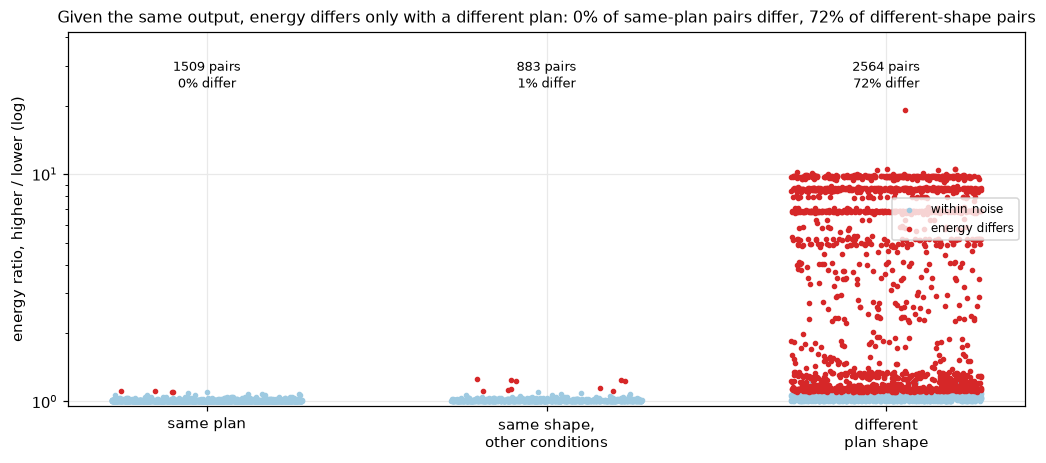

In [8]:
def plan_level(r):
    if r["same plan"]:
        return "same plan"
    if r["same plan shape, other conditions"]:
        return "same shape,\nother conditions"
    return "different\nplan shape"


Sp = Sp.assign(level=Sp.apply(plan_level, axis=1))
LEVELS = ["same plan", "same shape,\nother conditions", "different\nplan shape"]
fig, ax = plt.subplots(figsize=(9.5, 4.3))
rng = np.random.default_rng(0)
for i, lv in enumerate(LEVELS):
    d = Sp[Sp["level"] == lv]
    x = i + rng.uniform(-0.28, 0.28, len(d))
    ax.scatter(x[~d["energy_differs"].to_numpy()], d.loc[~d["energy_differs"], "ratio"], s=7, color="#9ecae1",
               zorder=3, label="within noise" if i == 0 else None)
    ax.scatter(x[d["energy_differs"].to_numpy()], d.loc[d["energy_differs"], "ratio"], s=7, color="#d62728",
               zorder=3, label="energy differs" if i == 0 else None)
    ax.text(i, Sp["ratio"].max() * 1.25, f"{len(d)} pairs\n{100 * d['energy_differs'].mean():.0f}% differ",
            ha="center", fontsize=8.5)
ax.set_yscale("log"); ax.set_ylim(0.95, Sp["ratio"].max() * 2.2)
ax.set_xticks(range(len(LEVELS))); ax.set_xticklabels(LEVELS)
ax.set_ylabel("energy ratio, higher / lower (log)"); ax.legend(fontsize=8, loc="center right")
lv_d = Sp.groupby("level")["energy_differs"].mean()
ax.set_title(f"Given the same output, energy differs only with a different plan: "
             f"{100 * lv_d.get('same plan', 0):.0f}% of same-plan pairs differ, "
             f"{100 * lv_d.get(LEVELS[2], 0):.0f}% of different-shape pairs", fontsize=10.5)
fig.tight_layout(); savefig(fig, "same_output_energy_by_plan"); plt.show()

#### What the more expensive SQL does differently

For the same-output pairs whose energy differs, orient each pair cheaper → more expensive and compare their
SQL features (from `csv/sqlstorm_query_features.csv`): how often the expensive version has
more of something, and how often the cheaper one does. A large gap between the two columns is a trend.

In [9]:
FCOLS = [("joins", "n_join"), ("tables referenced", "n_tables"), ("SELECTs (subqueries)", "n_select"),
         ("tokens", "tokens")]
BCOLS = [("CTE (WITH)", "is_cte"), ("window (OVER)", "has_window"), ("GROUP BY", "has_group"),
         ("DISTINCT", "has_distinct"), ("LEFT JOIN", "join_left"), ("ORDER BY", "has_order"), ("LIMIT", "has_limit")]
D = Sp[Sp["energy_differs"]].copy()
D["cheap"] = np.where(D["energy_a"] <= D["energy_b"], D["a"], D["b"])
D["dear"] = np.where(D["energy_a"] <= D["energy_b"], D["b"], D["a"])
rows = []
for lbl, c in FCOLS:
    x, y = FEAT.loc[D["dear"], c].to_numpy(), FEAT.loc[D["cheap"], c].to_numpy()
    rows.append({"feature": f"more {lbl}", "expensive has more (%)": 100 * (x > y).mean(),
                 "cheaper has more (%)": 100 * (x < y).mean()})
for lbl, c in BCOLS:
    x, y = FEAT.loc[D["dear"], c].astype(bool).to_numpy(), FEAT.loc[D["cheap"], c].astype(bool).to_numpy()
    rows.append({"feature": f"uses {lbl}", "expensive has more (%)": 100 * (x & ~y).mean(),
                 "cheaper has more (%)": 100 * (~x & y).mean()})
for lbl, k in [("launches parallel workers", "par"), ("spills to disk", "temp"), ("uses a top-N sort", "topn")]:
    x = np.array([PI[q][k] for q in D["dear"]]); y = np.array([PI[q][k] for q in D["cheap"]])
    rows.append({"feature": f"plan {lbl}", "expensive has more (%)": 100 * (x & ~y).mean(),
                 "cheaper has more (%)": 100 * (~x & y).mean()})
bx = np.array([PI[q]["buf"] for q in D["dear"]]); by = np.array([PI[q]["buf"] for q in D["cheap"]])
rows.append({"feature": "plan touches more buffers", "expensive has more (%)": 100 * (bx > by).mean(),
             "cheaper has more (%)": 100 * (bx < by).mean()})
DEAR = pd.DataFrame(rows).set_index("feature")
print(f"{len(D)} same-output pairs whose energy differs (median ratio {D['ratio'].median():.2f}):")
display(DEAR.round(1))

1851 same-output pairs whose energy differs (median ratio 5.15):


,expensive has more (%),cheaper has more (%)
feature,,
more joins,91.6,1.5
more tables referenced,88.7,3.0
more SELECTs (subqueries),3.6,1.9
more tokens,83.3,15.7
uses CTE (WITH),0.8,1.1
uses window (OVER),0.9,2.4
uses GROUP BY,0.1,0.0
uses DISTINCT,1.6,0.3
uses LEFT JOIN,1.0,0.4


The largest gaps between SQL texts with the same output, then the largest one in full.

In [10]:
def plan_diff_text(r):
    return ", ".join(k for k in list(PLAN_DIFFS)[2:] if r.get(k) is True) or ("same plan" if r.get("same plan") else "conditions only")


TOP = Sp.sort_values("ratio", ascending=False).head(12)
TOP_T = pd.DataFrame({"cheaper": np.where(TOP["energy_a"] <= TOP["energy_b"], TOP["a"], TOP["b"]),
                      "expensive": np.where(TOP["energy_a"] <= TOP["energy_b"], TOP["b"], TOP["a"]),
                      "relation": TOP["relation"], "rows": TOP["rows_a"],
                      "energy (J)": [f"{min(x, y):.2f} → {max(x, y):.2f}" for x, y in zip(TOP["energy_a"], TOP["energy_b"])],
                      "ratio": TOP["ratio"].round(1), "plan differences": TOP.apply(plan_diff_text, axis=1)})
with pd.option_context("display.max_colwidth", 120):
    display(TOP_T.reset_index(drop=True))
show_pair(int(TOP_T["cheaper"].iloc[0]), int(TOP_T["expensive"].iloc[0]))

,cheaper,expensive,relation,rows,energy (J),ratio,plan differences
0,15089,18293,renamed columns,10,0.53 → 10.12,19.2,"different tables read, different join methods, one parallel, one not"
1,12180,13981,identical,25,9.85 → 103.86,10.5,"different tables read, different join methods"
2,10210,13981,renamed columns,25,9.88 → 103.86,10.5,"different tables read, different join methods"
3,11658,13981,renamed columns,25,9.90 → 103.86,10.5,"different tables read, different join methods"
4,11987,13981,renamed columns,25,9.93 → 103.86,10.5,"different tables read, different join methods"
5,10730,13981,identical,25,9.95 → 103.86,10.4,"different tables read, different join methods"
6,12259,13820,renamed columns,25,10.49 → 106.69,10.2,"different tables read, different join methods"
7,11545,10661,renamed columns,25,10.74 → 109.01,10.1,"different tables read, different join methods"
8,10418,13820,renamed columns,25,10.52 → 106.69,10.1,"different tables read, different join methods"
9,11545,12680,identical,25,10.74 → 107.64,10.0,"different tables read, different join methods"


15089 vs 18293: renamed columns;  energy 0.53 J vs 10.12 J (19.23×);  copies 15 / 1

-- output of 15089 (10 rows, 2 columns)
p_brand|part_count
Brand#35  |8233
Brand#12  |8167
Brand#52  |8158

-- output of 18293 (10 rows, 2 columns)
p_brand|unique_parts
Brand#35  |8233
Brand#12  |8167
Brand#52  |8158

-- SQL diff
--- 15089
+++ 18293
@@ -1,5 +1,12 @@
-SELECT p_brand, COUNT(*) as part_count
-FROM part
-GROUP BY p_brand
-ORDER BY part_count DESC
+SELECT 
+    p_brand, 
+    COUNT(DISTINCT ps_partkey) AS unique_parts 
+FROM 
+    part 
+JOIN 
+    partsupp ON part.p_partkey = partsupp.ps_partkey 
+GROUP BY 
+    p_brand 
+ORDER BY 
+    unique_parts DESC 
 LIMIT 10;

-- plan diff (27 ms vs 1215 ms)
--- 15089
+++ 18293
@@ -2,5 +2,6 @@
-  Sort [Sort Key=(count(*)) DESC]
-    Finalize GroupAggregate [Group Key=p_brand]
-      Gather Merge
-        Partial GroupAggregate [Group Key=p_brand]
-          Parallel Index Only Scan on part
+  Sort [Sort Key=(count(DISTINCT partsupp.ps_partkey)) DESC

### 3b. Same plan, different output

§3 holds the output fixed: among queries returning the same data, the same plan meant the same energy (at most a
handful of pairs fall outside the noise, by little — first table below).
That does **not** carry over to queries whose outputs differ. The plan key (operators, tables, conditions) leaves
out three things that change how much work a plan does:

* the **`LIMIT` value** — a plain `EXPLAIN` shows a `Limit` node but not its count, and a larger limit runs the
  plan further;
* the **output expressions** — extra aggregates or computed columns are evaluated for every row, and are not in
  the plan text without `EXPLAIN (VERBOSE)`;
* **per-row subqueries** — a correlated subquery in the select list (a `SubPlan`) runs once per returned row, so
  it multiplies the first two.

Here every pair of variants with the same plan (and, separately, the same plan shape) is compared, whatever
they return. *Same output* = same rows (any of the §3 same-output relations, or both empty). The first table
splits by same / different output; the second takes the same-plan, different-output pairs and asks what
differs: the number of rows returned (the plan's actual row count), the number of output columns, and whether
the plan has a per-row subquery.

In [11]:
SAME_REL = {frozenset((a, b)) for a, b, r in zip(REL["a"], REL["b"], REL["relation"]) if r in SAME}


def same_output(a, b):
    return frozenset((a, b)) in SAME_REL or (a in RAW and b in RAW and RAW[a][1] == RAW[b][1])


def has_subplan(q):
    return any((n["label"] or "").startswith("SubPlan") for n in PLANS[q]["nodes"])


VP = [r for r in VAR if r in PLANS and pd.notna(VE.at[r, "energy_j"])]
SUBP = {r: has_subplan(r) for r in VP}
rows = []
for key, col in [("same plan", "plan_hash"), ("same plan shape", "plan_shape_hash")]:
    grp = collections.defaultdict(list)
    for r in VP:
        grp[PL.at[r, col]].append(r)
    for g in grp.values():
        for a, b in itertools.combinations(sorted(g), 2):
            ea, eb = VE.at[a, "energy_j"], VE.at[b, "energy_j"]
            ratio = max(ea, eb) / min(ea, eb)
            rows.append({"key": key, "a": a, "b": b, "same output": same_output(a, b),
                         "energy_a": ea, "energy_b": eb, "ratio": ratio,
                         "energy differs": bool(abs(ea - eb) > 3 * np.hypot(VE.at[a, "energy_se"], VE.at[b, "energy_se"])
                                                and ratio >= 1.1),
                         "rows_a": PL.at[a, "root_rows"], "rows_b": PL.at[b, "root_rows"],
                         "ncol_a": len(RAW[a][0]) if a in RAW else np.nan, "ncol_b": len(RAW[b][0]) if b in RAW else np.nan,
                         "buffers_a": PL.at[a, "shared_hit"] + PL.at[a, "shared_read"],
                         "buffers_b": PL.at[b, "shared_hit"] + PL.at[b, "shared_read"],
                         "per-row subquery": SUBP[a] or SUBP[b]})
SP = pd.DataFrame(rows)
SP["output"] = np.where(SP["same output"], "same output", "different output")
SP_SUM = (SP.groupby(["key", "output"])
          .agg(pairs=("a", "size"), **{"energy differs (%)": ("energy differs", lambda s: 100 * s.mean())},
               **{"median ratio": ("ratio", "median")}, **{"90th pct ratio": ("ratio", lambda s: s.quantile(0.9))},
               **{"largest ratio": ("ratio", "max")}))
display(SP_SUM.round(3))

SPD = SP[(SP["key"] == "same plan") & ~SP["same output"]].copy()
SPD["what differs"] = np.select(
    [SPD["rows_a"] != SPD["rows_b"], SPD["ncol_a"] != SPD["ncol_b"]],
    ["number of rows returned", "same row count, number of columns"], "same row and column count (other values or expressions)")
SPD["buffers ratio"] = SPD[["buffers_a", "buffers_b"]].max(axis=1) / SPD[["buffers_a", "buffers_b"]].min(axis=1).clip(lower=1)
SP_WHY = (SPD.groupby(["what differs", "per-row subquery"])
          .agg(pairs=("a", "size"), **{"energy differs (%)": ("energy differs", lambda s: 100 * s.mean())},
               **{"median ratio": ("ratio", "median")}, **{"largest ratio": ("ratio", "max")},
               **{"median buffers ratio": ("buffers ratio", "median")}))
print(f"Same plan, different output: {len(SPD)} pairs; what differs between the two (rows from the plan's "
      f"actual row count, columns from the output header):")
display(SP_WHY.round(3))
diff = SPD[SPD["energy differs"]]
print(f"Of the {len(diff)} same-plan pairs whose energy differs, the plan with more energy also touches more "
      f"buffers in {100 * ((diff['energy_a'] > diff['energy_b']) == (diff['buffers_a'] > diff['buffers_b'])).mean():.0f}%.")

pairs  energy differs (%)  median ratio  \
key             output                                                      
same plan       different output   1457              30.748         1.037   
                same output        1520               0.263         1.005   
same plan shape different output  40855              54.473         1.129   
                same output        4976               2.070         1.012   

                                  90th pct ratio  largest ratio  
key             output                                           
same plan       different output           1.327          3.377  
                same output                1.017          1.112  
same plan shape different output          10.085         84.290  
                same output                1.076         59.541

Same plan, different output: 1457 pairs; what differs between the two (rows from the plan's actual row count, columns from the output header):


,,pairs,energy differs (%),median ratio,largest ratio,median buffers ratio
what differs,per-row subquery,,,,,
number of rows returned,False,479,10.438,1.014,1.596,1.0
same row and column count (other values or expressions),False,186,23.118,1.025,1.543,1.0
"same row count, number of columns",False,792,44.823,1.070,3.377,1.0


Of the 448 same-plan pairs whose energy differs, the plan with more energy also touches more buffers in 58%.


In [12]:
SP_TOP = SPD.sort_values("ratio", ascending=False).head(10)
SP_TOP_T = pd.DataFrame({
    "cheaper": np.where(SP_TOP["energy_a"] <= SP_TOP["energy_b"], SP_TOP["a"], SP_TOP["b"]),
    "expensive": np.where(SP_TOP["energy_a"] <= SP_TOP["energy_b"], SP_TOP["b"], SP_TOP["a"]),
    "energy (J)": [f"{min(x, y):.2f} → {max(x, y):.2f}" for x, y in zip(SP_TOP["energy_a"], SP_TOP["energy_b"])],
    "ratio": SP_TOP["ratio"].round(2),
    "rows": [f"{a:.0f} / {b:.0f}" for a, b in zip(SP_TOP["rows_a"], SP_TOP["rows_b"])],
    "columns": [f"{a:.0f} / {b:.0f}" for a, b in zip(SP_TOP["ncol_a"], SP_TOP["ncol_b"])],
    "buffers": [f"{a / 1e3:.0f} k / {b / 1e3:.0f} k" for a, b in zip(SP_TOP["buffers_a"], SP_TOP["buffers_b"])],
    "per-row subquery": SP_TOP["per-row subquery"], "what differs": SP_TOP["what differs"]})
print("Largest gaps between queries with the same plan (rows, columns and buffers as a / b of the pair):")
display(SP_TOP_T.reset_index(drop=True))
ex = SP_TOP.iloc[0]
print(f"\nThe largest, {int(ex['a'])} vs {int(ex['b'])}, side by side:")
for q in (int(ex["a"]), int(ex["b"])):
    print(f"\n{q}: {VE.at[q, 'energy_j']:.2f} J, {PL.at[q, 'root_rows']:.0f} rows, "
          f"{(PL.at[q, 'shared_hit'] + PL.at[q, 'shared_read']) / 1e3:.0f} k buffers")
    print(sql_body(q)[:900])
print("\nSame plan for both:")
pl_show(int(ex["a"]), cond=False) if "pl_show" in globals() else print(plan_signature(PLANS[int(ex["a"])], False))

Largest gaps between queries with the same plan (rows, columns and buffers as a / b of the pair):


,cheaper,expensive,energy (J),ratio,rows,columns,buffers,per-row subquery,what differs
0,16132,29082,0.62 → 2.09,3.38,1 / 1,2 / 4,4 k / 4 k,False,"same row count, number of columns"
1,17461,17863,10.83 → 29.47,2.72,4 / 4,3 / 7,113 k / 113 k,False,"same row count, number of columns"
2,17461,16330,10.83 → 29.41,2.72,4 / 4,6 / 3,113 k / 113 k,False,"same row count, number of columns"
3,15242,17863,12.49 → 29.47,2.36,4 / 4,4 / 7,113 k / 113 k,False,"same row count, number of columns"
4,15242,16330,12.49 → 29.41,2.35,4 / 4,4 / 6,113 k / 113 k,False,"same row count, number of columns"
5,18987,28977,0.60 → 1.10,1.84,1 / 1,2 / 7,4 k / 4 k,False,"same row count, number of columns"
6,18877,13642,4.78 → 7.88,1.65,1 / 1,10 / 3,106 k / 106 k,False,"same row count, number of columns"
7,18877,14015,4.78 → 7.88,1.65,1 / 1,7 / 3,106 k / 106 k,False,"same row count, number of columns"
8,16696,11049,4.98 → 8.09,1.62,4 / 4,10 / 4,106 k / 106 k,False,"same row count, number of columns"
9,13695,11049,4.99 → 8.09,1.62,4 / 4,10 / 3,106 k / 106 k,False,"same row count, number of columns"



The largest, 16132 vs 29082, side by side:

16132: 0.62 J, 1 rows, 4 k buffers
SELECT COUNT(*) AS total_parts, AVG(p_retailprice) AS average_price
FROM part
WHERE p_size > 10;

29082: 2.09 J, 1 rows, 4 k buffers
WITH StringProcessing AS (
    SELECT 
        p.p_name AS part_name,
        CONCAT('Part Name: ', p.p_name, ', Brand: ', p.p_brand, ', Type: ', p.p_type) AS detailed_info,
        LENGTH(p.p_comment) AS comment_length,
        REPLACE(p.p_comment, 'quality', 'excellence') AS adjusted_comment,
        UPPER(SUBSTRING(p.p_name, 1, 10)) AS upper_part_name,
        LOWER(p.p_brand) AS lower_brand
    FROM 
        part p
    WHERE 
        p.p_size > 10
)
SELECT 
    STRING_AGG(detailed_info, '; ') AS aggregated_info,
    AVG(comment_length) AS avg_comment_length,
    MAX(upper_part_name) AS max_upper_part_name,
    MIN(lower_brand) AS min_lower_brand
FROM 
    StringProcessing;

Same plan for both:
Finalize Aggregate
  Gather
    Partial Aggregate
      Parallel Seq Scan on par

**Reading §3 and §3b together.** With the output held fixed, the plan decides the energy: same-plan pairs
practically never differ. Across different outputs, the same plan is a strong grouping but not a guarantee. Most same-plan pairs
still cost the same, and where they do not the gap is usually small — a few percent, rarely above 2× — whatever
differs between the outputs (rows, columns or values). These gaps come from what is computed and returned per
row: more or heavier output expressions, more rows. They do not show in the buffer counts (the same plan reads
the same data, so the extra cost is CPU, not reading), which is why the energy and buffer differences agree only
about half the time. The one large kind is a **per-row subquery combined with a larger `LIMIT`**: the subquery
runs once for every extra row, the buffers grow with it, and the energy gap reaches 6×.

A key that pins energy down therefore needs the plan **plus** the `LIMIT` value and the output expressions
(`EXPLAIN (VERBOSE)` prints the latter). SQL text alone and output alone are not enough either way: §3 shows
the same output at very different cost.

## 4. Renamed versions of the same output

The same data under other column names (and possibly another column order). The table lists the groups of
variants that return the same data, with the column names each one uses; for large groups only the first
names are shown. Energy spread is the max/min of the variants' energies.

In [13]:
REN = REL[REL["relation"].isin(["renamed columns", "reordered columns"])]
parent = {}


def find(x):
    while parent.setdefault(x, x) != x:
        parent[x] = parent[parent[x]]; x = parent[x]
    return x


for a, b in zip(REN["a"], REN["b"]):
    parent[find(a)] = find(b)
for a, b in zip(REL.loc[REL["relation"] == "identical", "a"], REL.loc[REL["relation"] == "identical", "b"]):
    if a in parent or b in parent:
        parent[find(a)] = find(b)
groups = collections.defaultdict(list)
for x in list(parent):
    groups[find(x)].append(x)
RG = sorted((sorted(g) for g in groups.values()), key=len, reverse=True)
rows = []
for g in RG:
    e = VE.loc[g, "energy_j"].dropna()
    names = collections.Counter("|".join(sorted(OUT[q].header)) for q in g)
    rows.append({"variants": len(g), "queries": sum(len(VAR[q]) for q in g), "rows": OUT[g[0]].n,
                 "column names used": len(names),
                 "examples of headers": "  /  ".join("|".join(OUT[q].header) for q in g[:3]),
                 "energy min–max (J)": f"{e.min():.2f}–{e.max():.2f}" if len(e) else "",
                 "max/min": e.max() / e.min() if len(e) > 1 else np.nan, "variant ids": " ".join(map(str, g[:8])) + (" …" if len(g) > 8 else "")})
RGT = pd.DataFrame(rows)
print(f"{len(RGT)} groups of renamed or reordered versions ({int(RGT['variants'].sum())} variants, "
      f"{int(RGT['queries'].sum())} queries); max/min energy within a group: median {RGT['max/min'].median():.2f}, "
      f"≥ 1.5× in {int((RGT['max/min'] >= 1.5).sum())} groups")
with pd.option_context("display.max_colwidth", 110):
    display(RGT.head(15).round(2))

334 groups of renamed or reordered versions (1373 variants, 2709 queries); max/min energy within a group: median 1.05, ≥ 1.5× in 77 groups


,variants,queries,rows,column names used,examples of headers,energy min–max (J),max/min,variant ids
0,27,48,10,4,n_name|total_revenue / nation_name|total_revenue / nation_name|total_revenue,10.55–104.17,9.87,10154 10318 10341 10391 10514 10541 10672 10767 …
1,26,72,10,2,p_name|total_revenue / p_name|total_revenue / p_name|revenue,9.91–68.69,6.93,12052 12666 14117 15042 15074 15098 15101 15219 …
2,26,111,10,5,n_name|total_revenue / nation|total_revenue / nation_name|total_revenue,30.79–219.01,7.11,10003 10008 10026 10034 10037 10111 10311 10334 …
3,22,48,10,5,nation|total_revenue / n_name|revenue / n_name|total_revenue,72.37–83.59,1.15,10012 10051 10260 10303 10355 10431 10502 10987 …
4,22,46,25,3,nation|total_revenue / nation|total_revenue / n_name|total_revenue,10.49–104.55,9.96,10042 10256 10485 10631 10687 11180 11293 12108 …
5,18,49,25,5,n_name|revenue / n_name|revenue / n_name|revenue,10.57–104.60,9.89,10025 10144 10179 10283 10364 10464 10694 10829 …
6,17,33,25,4,n_name|total_revenue / n_name|revenue / nation|total_revenue,31.59–219.18,6.94,10039 10076 10155 10263 10556 10823 11437 11495 …
7,17,30,25,4,n_name|revenue / n_name|total_revenue / n_name|revenue,19.05–21.34,1.12,10080 10310 10352 10511 10951 11215 11668 11871 …
8,15,33,10,5,total_revenue|nation_name / n_name|total_revenue / n_name|total_revenue,27.10–216.54,7.99,10067 10194 10495 10532 10591 10681 10907 11442 …
9,15,34,25,4,n_name|revenue / n_name|total_revenue / n_name|total_revenue,71.36–83.33,1.17,10020 10339 10466 11456 11719 11968 11979 13918 …


## 5. Limited versions: the same data, fewer rows

A's rows are the first rows of B (nearest step: the B with the fewest extra rows), with all of A's columns or
some of them. Does returning fewer rows save energy, and does the plan change?

In [14]:
L = REL[REL["nearest"] & REL["relation"].isin(["limited", "limited + fewer columns"]) & REL["energy_differs"].notna()].copy()
L["energy_differs"] = L["energy_differs"].astype(bool)
L["row ratio"] = pd.cut(L["rows_b"] / L["rows_a"], [1, 2, 5, 20, np.inf], labels=["≤ 2×", "2–5×", "5–20×", "> 20×"],
                        include_lowest=True)
L["B reads other tables"] = L["different tables read"].astype(bool)
LIM = (L.groupby(["relation", "B reads other tables"], observed=True)
       .agg(pairs=("a", "size"), **{"median energy B/A": ("b_over_a", "median")},
            **{"energy differs (%)": ("energy_differs", lambda s: 100 * s.mean())},
            **{"same plan shape (%)": ("same plan shape, other conditions", lambda s: 100 * (s.astype(bool) | L.loc[s.index, "same plan"].astype(bool)).mean())}))
display(LIM.round(2))
LIM_ROWS = (L[L["relation"] == "limited"].groupby("row ratio", observed=True)
            .agg(pairs=("a", "size"), **{"median energy B/A": ("b_over_a", "median")},
                 **{"energy differs (%)": ("energy_differs", lambda s: 100 * s.mean())}))
print("'limited' only (same columns), by how many more rows B returns:")
display(LIM_ROWS.round(2))

pairs  median energy B/A  \
relation                B reads other tables                             
limited                 False                   415               1.00   
                        True                    206               0.96   
limited + fewer columns False                   243               1.05   
                        True                    622               1.32   

                                              energy differs (%)  \
relation                B reads other tables                       
limited                 False                               4.58   
                        True                               63.59   
limited + fewer columns False                              46.91   
                        True                               78.14   

                                              same plan shape (%)  
relation                B reads other tables                       
limited                 False                               31.08  
                        True                                 0.97  
limited + fewer columns False                               50.21  
                        True                                 0.00

'limited' only (same columns), by how many more rows B returns:


,pairs,median energy B/A,energy differs (%)
row ratio,,,
≤ 2×,21,1.01,19.05
2–5×,316,1.00,30.06
5–20×,172,1.00,18.02
> 20×,112,1.01,17.86


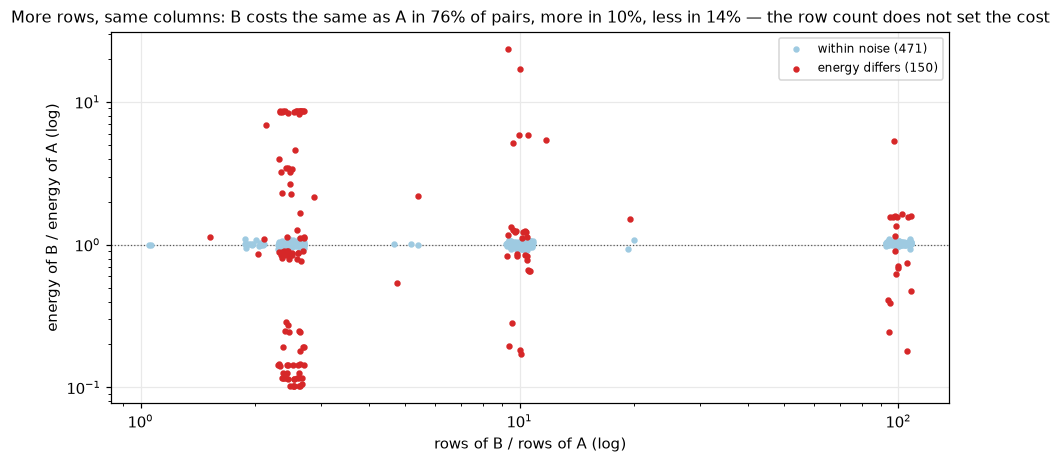

11663 vs 12863: limited;  energy 0.36 J vs 8.45 J (23.64×);  copies 1 / 1

-- output of 11663 (100 rows, 5 columns)
p_partkey|p_name|s_name|ps_availqty|ps_supplycost
1|goldenrod lavender spring chocolate lace|Supplier#000000002       |3325|771.64
1|goldenrod lavender spring chocolate lace|Supplier#000002502       |8076|993.49
1|goldenrod lavender spring chocolate lace|Supplier#000005002       |3956|337.09

-- output of 12863 (1000 rows, capped, 5 columns)
p_partkey|p_name|s_name|ps_availqty|ps_supplycost
1|goldenrod lavender spring chocolate lace|Supplier#000000002       |3325|771.64
1|goldenrod lavender spring chocolate lace|Supplier#000002502       |8076|993.49
1|goldenrod lavender spring chocolate lace|Supplier#000005002       |3956|337.09

-- SQL diff
--- 11663
+++ 12863
@@ -13,5 +13,4 @@
 WHERE 
-    ps.ps_availqty > 0 
+    ps.ps_availqty > 100 
 ORDER BY 
-    p.p_partkey 
-LIMIT 100;
+    p.p_partkey, s.s_name;

-- plan diff (1 ms vs 960 ms)
--- 11663
+++ 12863
@@ -1 +1 @@
-Lim

In [15]:
Lo = L[L["relation"] == "limited"]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
jit = np.exp(np.random.default_rng(1).uniform(-0.08, 0.08, len(Lo)))       # spread the stacked row ratios
for flag, col, lbl in [(False, "#9ecae1", "within noise"), (True, "#d62728", "energy differs")]:
    m = (Lo["energy_differs"] == flag).to_numpy()
    d = Lo[m]
    ax.scatter(d["rows_b"] / d["rows_a"] * jit[m], d["b_over_a"], s=10, color=col, label=f"{lbl} ({len(d)})", zorder=3)
ax.axhline(1, color="#555", lw=0.8, ls=":")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("rows of B / rows of A (log)"); ax.set_ylabel("energy of B / energy of A (log)")
ax.legend(fontsize=8)
more = 100 * (Lo["energy_differs"] & (Lo["b_over_a"] > 1)).mean()
less = 100 * (Lo["energy_differs"] & (Lo["b_over_a"] < 1)).mean()
ax.set_title(f"More rows, same columns: B costs the same as A in {100 - more - less:.0f}% of pairs, more in "
             f"{more:.0f}%, less in {less:.0f}% — the row count does not set the cost", fontsize=10.5)
fig.tight_layout(); savefig(fig, "limited_energy"); plt.show()
ex = Lo.sort_values("b_over_a", ascending=False).iloc[0]
show_pair(int(ex["a"]), int(ex["b"]))

## 6. Narrower versions: the same rows, fewer columns

A's columns are some of B's columns over the same rows (nearest step: the B with the fewest extra columns).
The extra columns of B often come from extra joins — a count of comments, a sum of votes — so the table splits
the pairs by whether B's plan reads tables A's does not.

In [16]:
W = REL[REL["nearest"] & REL["relation"].isin(["fewer columns", "fewer columns, reordered rows"]) & REL["energy_differs"].notna()].copy()
W["energy_differs"] = W["energy_differs"].astype(bool)
W["B reads other tables"] = W["different tables read"].astype(bool)
W["extra columns"] = pd.cut(W["ncol_b"] - W["ncol_a"], [0, 1, 2, 4, np.inf], labels=["1", "2", "3–4", "5+"])
WID = (W.groupby(["B reads other tables", "extra columns"], observed=True)
       .agg(pairs=("a", "size"), **{"median energy B/A": ("b_over_a", "median")},
            **{"energy differs (%)": ("energy_differs", lambda s: 100 * s.mean())},
            **{"B more expensive (%)": ("b_over_a", lambda s: 100 * (s > 1).mean())}))
display(WID.round(2))
WD = W[W["energy_differs"]]
print(f"\nPlan differences in the {len(WD)} narrower/wider pairs whose energy differs (%):")
display((100 * WD[list(PLAN_DIFFS)].astype(float).mean()).round(1).to_frame("pairs with it (%)"))
ex = W[~W["B reads other tables"]].sort_values("b_over_a", ascending=False).iloc[0]
print("\nLargest gap where B reads no extra table:")
show_pair(int(ex["a"]), int(ex["b"]))

pairs  median energy B/A  \
B reads other tables extra columns                             
False                1                465               1.04   
                     2                 29               1.08   
                     3–4               22               1.14   
                     5+                 6               1.24   
True                 1                477               1.11   
                     2                114               2.24   
                     3–4               90               1.79   
                     5+                19               1.34   

                                    energy differs (%)  B more expensive (%)  
B reads other tables extra columns                                            
False                1                           33.98                 81.51  
                     2                           48.28                 79.31  
                     3–4                         59.09                 86.36  
                     5+                          50.00                100.00  
True                 1                           65.83                 77.99  
                     2                           84.21                 84.21  
                     3–4                         85.56                 77.78  
                     5+                          94.74                 57.89


Plan differences in the 693 narrower/wider pairs whose energy differs (%):


,pairs with it (%)
same plan,5.2
"same plan shape, other conditions",5.5
different tables read,72.9
different join methods,72.2
different scan methods (same tables),9.1
"one parallel, one not",14.1
"one spills to disk, one not",25.4
"one uses a top-N sort, one not",5.1



Largest gap where B reads no extra table:
15057 vs 17327: fewer columns, reordered rows;  energy 3.38 J vs 26.24 J (7.77×);  copies 3 / 2

-- output of 15057 (10 rows, 3 columns)
p_name|s_name|ps_supplycost
drab almond rosy azure blanched|Supplier#000001555       |1000.00
aquamarine blue smoke rosy cornflower|Supplier#000003944       |1000.00
sienna cyan light snow hot|Supplier#000005851       |1000.00

-- output of 17327 (10 rows, 4 columns)
p_name|s_name|total_availqty|total_supplycost
sienna cyan light snow hot|Supplier#000005851       |9994|1000.00
aquamarine blue smoke rosy cornflower|Supplier#000003944       |5065|1000.00
wheat pink slate orchid beige|Supplier#000007435       |7911|1000.00

-- SQL diff
--- 15057
+++ 17327
@@ -1,15 +1,16 @@
-SELECT 
-    p.p_name, 
-    s.s_name, 
-    ps.ps_supplycost 
-FROM 
-    part p 
-JOIN 
-    partsupp ps ON p.p_partkey = ps.ps_partkey 
-JOIN 
-    supplier s ON ps.ps_suppkey = s.s_suppkey 
-WHERE 
-    ps.ps_availqty > 10 
-ORDER BY 
-  

## 7. Subsets: some of the same rows

Every row of A is a row of B, but not B's first rows — a stricter filter, or another order before a limit.

In [17]:
U = REL[REL["nearest"] & (REL["relation"] == "subset of rows") & REL["energy_differs"].notna()].copy()
U["energy_differs"] = U["energy_differs"].astype(bool)
print(f"{len(U)} nearest-step subset pairs: median energy B/A {U['b_over_a'].median():.2f}, energy differs in "
      f"{100 * U['energy_differs'].mean():.0f}%, B returns median {(U['rows_b'] / U['rows_a']).median():.1f}× the rows")
display((100 * U[list(PLAN_DIFFS)].astype(float).mean()).round(1).to_frame("pairs with it (%)"))
ex = U.sort_values("ratio", ascending=False).iloc[0]
show_pair(int(ex["a"]), int(ex["b"]))

328 nearest-step subset pairs: median energy B/A 1.02, energy differs in 51%, B returns median 10.0× the rows


,pairs with it (%)
same plan,7.0
"same plan shape, other conditions",23.5
different tables read,42.7
different join methods,40.5
different scan methods (same tables),6.1
"one parallel, one not",12.8
"one spills to disk, one not",22.0
"one uses a top-N sort, one not",36.9


18293 vs 15444: subset of rows;  energy 10.12 J vs 0.52 J (0.05×);  copies 1 / 5

-- output of 18293 (10 rows, 2 columns)
p_brand|unique_parts
Brand#35  |8233
Brand#12  |8167
Brand#52  |8158

-- output of 15444 (25 rows, 2 columns)
p_brand|part_count
Brand#35  |8233
Brand#12  |8167
Brand#52  |8158

-- SQL diff
--- 18293
+++ 15444
@@ -1,12 +1,4 @@
-SELECT 
-    p_brand, 
-    COUNT(DISTINCT ps_partkey) AS unique_parts 
-FROM 
-    part 
-JOIN 
-    partsupp ON part.p_partkey = partsupp.ps_partkey 
-GROUP BY 
-    p_brand 
-ORDER BY 
-    unique_parts DESC 
-LIMIT 10;
+SELECT p_brand, COUNT(*) as part_count
+FROM part
+GROUP BY p_brand
+ORDER BY part_count DESC;

-- plan diff (1215 ms vs 26 ms)
--- 18293
+++ 15444
@@ -1,7 +1,5 @@
-Limit
-  Sort [Sort Key=(count(DISTINCT partsupp.ps_partkey)) DESC]
-    GroupAggregate [Group Key=part.p_brand]
-      Sort [Sort Key=part.p_brand, partsupp.ps_partkey]
-        Merge Join [Merge Cond=(part.p_partkey = partsupp.ps_partkey)]
-          Index Sc

## 8. Export

`csv/sqlstorm_tpch_output_relations.csv`: every same-output pair (§3–4) and every nearest-step
containment pair (§5–7). Queries are the representatives of their copy sets (`a_copies` / `b_copies` list
all query numbers of each set); A is the side with fewer rows. Energies are SQLStorm single-copy energy (laptop 1) (median
over copies); the plan columns compare the two `EXPLAIN ANALYZE` plans.

In [18]:
X = REL[REL["nearest"]].copy()
X["a_copies"] = X["a"].map(lambda q: ";".join(map(str, VAR[q])))
X["b_copies"] = X["b"].map(lambda q: ";".join(map(str, VAR[q])))
X["plan_differences"] = X.apply(lambda r: plan_diff_text(r) if r["a"] in PI and r["b"] in PI else "", axis=1)
cols = ["a", "b", "relation", "a_copies", "b_copies", "rows_a", "rows_b", "ncol_a", "ncol_b", "capped",
        "energy_a", "energy_b", "b_over_a", "energy_differs", "same plan", "same plan shape, other conditions",
        "plan_differences", "buffers_ratio"]
X = X[cols].rename(columns={"a": "query_a", "b": "query_b", "energy_a": "energy_a_j", "energy_b": "energy_b_j",
                            "b_over_a": "energy_b_over_a", "same plan": "same_plan",
                            "same plan shape, other conditions": "same_plan_shape_other_conditions"})
X = X.sort_values(["relation", "query_a", "query_b"])
X.to_csv("csv/sqlstorm_tpch_output_relations.csv", index=False)
print(f"wrote csv/sqlstorm_tpch_output_relations.csv ({len(X)} rows)")
display(X["relation"].value_counts().to_frame("rows"))

wrote csv/sqlstorm_tpch_output_relations.csv (7992 rows)


,rows
relation,
renamed columns,2740
identical,1834
fewer columns,1062
limited + fewer columns,865
limited,621
subset of rows,328
reordered columns,200
reordered rows,182
"fewer columns, reordered rows",160


## 9. Browsable pages: the largest gaps, and the largest copy sets

For reading the cases outside the notebook, written as a small static website to `export/similar_output_pairs_tpch/` (open
`index.html`; no server needed). Variants are grouped four ways, one tab each:

* **same plan** — same operators, tables and conditions (§3b);
* **same plan shape** — same operators and tables, conditions may differ;
* **same output** — the same rows, whatever the plan: identical, renamed or reordered columns, reordered rows
  (§3; groups joined through those relations; empty results left out);
* **same query** — copies of one SQL text (same sqlglot canonical form), the 20 largest copy sets.

For the first three, a group's gap is its most expensive variant's energy over its cheapest's; only gaps beyond the
noise rule of §3 count, and the 20 groups with the largest gap get a page each (ranking groups rather than pairs keeps
one large group from filling the list). A page shows the group summary, the cheapest and the most expensive SQL side by
side — energy, rows, plan time, buffers, the SQL, the first rows of the output, the plan — the plan difference, and
every variant of the group. A same-query page shows how the copies' energy, outputs and plans compare, and every
distinct SQL text in full with the copies that use it, so a reader can see the copies differ only in formatting, case
or names. The sidebar moves between the 20 pages of a tab; `index.html` lists them all, and `index.csv` holds the same
list as data.

In [19]:
import shutil, html
PAIR_DIR = Path("export/similar_output_pairs_tpch")
TOP_N = 20
KIND_TITLE = {"same_plan": "Same plan", "same_plan_shape": "Same plan shape", "same_output": "Same output",
              "same_query": "Same query"}
KIND_DESC = {"same_plan": "same plan (operators, tables and conditions); outputs may differ",
             "same_plan_shape": "same plan shape (operators and tables); conditions and outputs may differ",
             "same_output": "same output (same rows: identical, renamed or reordered columns, reordered rows); plans may differ",
             "same_query": "copies of one SQL text (same sqlglot canonical form): the largest copy sets"}


def union_groups(pairs):
    parent = {}

    def find(x):
        parent.setdefault(x, x)
        while parent[x] != x:
            parent[x] = parent[parent[x]]; x = parent[x]
        return x
    for a, b in pairs:
        parent[find(a)] = find(b)
    g = collections.defaultdict(list)
    for x in list(parent):
        g[find(x)].append(x)
    return list(g.values())


def groups_by(col):
    g = collections.defaultdict(list)
    for r in VP:
        g[PL.at[r, col]].append(r)
    return list(g.values())


has_e = set(VE.index[VE["energy_j"].notna()])
GROUPS = {"same_plan": groups_by("plan_hash"), "same_plan_shape": groups_by("plan_shape_hash"),
          "same_output": union_groups((a, b) for a, b, r in zip(REL["a"], REL["b"], REL["relation"]) if r in SAME)}
GROUPS = {k: [sorted((q for q in g if q in has_e), key=lambda q: VE.at[q, "energy_j"]) for g in v] for k, v in GROUPS.items()}
GROUPS = {k: [g for g in v if len(g) >= 2] for k, v in GROUPS.items()}


def gap(g):
    lo, hi = g[0], g[-1]
    elo, ehi = VE.at[lo, "energy_j"], VE.at[hi, "energy_j"]
    beyond = abs(ehi - elo) > 3 * np.hypot(VE.at[lo, "energy_se"], VE.at[hi, "energy_se"]) and ehi / elo >= 1.1
    return ehi / elo, beyond


def out_key(q):
    return h(RAW[q][1]) if q in RAW else None


def plan_text(q):
    return plan_signature(PLANS[q]).splitlines() if q in PLANS else ["(no plan)"]


def sq_nocomment(t):
    return re.sub(r"/\*.*?\*/", " ", re.sub(r"--[^\n]*", " ", t), flags=re.S)


def sq_ws(t):
    return re.sub(r"\s+", " ", t).strip().rstrip(";").strip()


def sq_verdict(a, b):
    """What separates two SQL texts that share a canonical form, checked step by step."""
    if sq_ws(a) == sq_ws(b):
        return "only whitespace / line breaks"
    if sq_ws(sq_nocomment(a)) == sq_ws(sq_nocomment(b)):
        return "only whitespace and comments"
    if sq_ws(sq_nocomment(a)).lower() == sq_ws(sq_nocomment(b)).lower():
        return "only whitespace, comments and upper/lower case"
    return "names (table aliases, output column names or CTE names), besides any whitespace, comment or case changes"


ENTRIES = {}
for kind, groups in GROUPS.items():
    ranked = sorted((g for g in groups if gap(g)[1]), key=lambda g: gap(g)[0], reverse=True)[:TOP_N]
    ENTRIES[kind] = [dict(kind=kind, rank=i, g=g, lo=g[0], hi=g[-1], ratio=gap(g)[0]) for i, g in enumerate(ranked, 1)]
SQ = sorted((g for g in VAR.values() if len(g) > 1), key=lambda g: (-len(g), g[0]))[:TOP_N]
ENTRIES["same_query"] = []
for i, g in enumerate(SQ, 1):
    e = E2["energy_j"].reindex(g)
    by_text = collections.defaultdict(list)
    for q in g:
        by_text[sql_body(q)].append(q)
    texts = sorted(by_text.items(), key=lambda kv: (-len(kv[1]), kv[1][0]))
    ENTRIES["same_query"].append(dict(kind="same_query", rank=i, g=g, rep=g[0], e=e, texts=texts,
                                      lo=e.idxmin() if e.notna().any() else None,
                                      hi=e.idxmax() if e.notna().any() else None,
                                      ratio=e.max() / e.min() if e.notna().any() else np.nan))
for kind in GROUPS:
    print(f"{kind:16} {len(GROUPS[kind]):5} groups of ≥ 2 variants with energy, "
          f"{sum(gap(g)[1] for g in GROUPS[kind]):5} with a gap beyond noise; {len(ENTRIES[kind])} pages")
print(f"{'same_query':16} {sum(len(g) > 1 for g in VAR.values()):5} copy sets of ≥ 2 queries; {len(ENTRIES['same_query'])} pages")

same_plan          509 groups of ≥ 2 variants with energy,    68 with a gap beyond noise; 20 pages
same_plan_shape    701 groups of ≥ 2 variants with energy,   374 with a gap beyond noise; 20 pages
same_output        481 groups of ≥ 2 variants with energy,   171 with a gap beyond noise; 20 pages
same_query         752 copy sets of ≥ 2 queries; 20 pages


In [20]:
E_ = html.escape
CSS = """
:root { --bg:#ffffff; --fg:#1f2328; --muted:#59636e; --line:#d1d9e0; --panel:#f6f8fa; --accent:#0969da;
        --accent-bg:#ddf4ff; --cheap:#1a7f37; --dear:#cf222e; --add:#dafbe1; --del:#ffebe9; --code:#f6f8fa; }
@media (prefers-color-scheme: dark) {
  :root { --bg:#0d1117; --fg:#e6edf3; --muted:#9198a1; --line:#3d444d; --panel:#151b23; --accent:#4493f8;
          --accent-bg:#121d2f; --cheap:#3fb950; --dear:#f85149; --add:#12261e; --del:#25171c; --code:#151b23; } }
* { box-sizing: border-box; }
body { margin:0; background:var(--bg); color:var(--fg); font:14px/1.5 system-ui,-apple-system,"Segoe UI",sans-serif; }
a { color:var(--accent); text-decoration:none; } a:hover { text-decoration:underline; }
header { position:sticky; top:0; z-index:5; background:var(--panel); border-bottom:1px solid var(--line); }
.brand { padding:10px 20px 0; font-weight:600; }
.brand small { color:var(--muted); font-weight:400; margin-left:8px; }
nav.tabs { display:flex; gap:4px; padding:8px 16px 0; flex-wrap:wrap; }
nav.tabs a { padding:7px 14px; border:1px solid transparent; border-bottom:none; border-radius:6px 6px 0 0; color:var(--fg); }
nav.tabs a.on { background:var(--bg); border-color:var(--line); font-weight:600; margin-bottom:-1px; }
.wrap { display:flex; min-height:calc(100vh - 80px); }
aside { width:250px; flex:none; border-right:1px solid var(--line); padding:12px 0; position:sticky; top:80px;
        align-self:flex-start; max-height:calc(100vh - 80px); overflow:auto; }
aside a { display:block; padding:5px 16px; color:var(--fg); font-size:13px; border-left:3px solid transparent; }
aside a .r { color:var(--muted); display:inline-block; width:30px; }
aside a .x { float:right; color:var(--muted); }
aside a.on { background:var(--accent-bg); border-left-color:var(--accent); font-weight:600; }
main { flex:1; min-width:0; padding:20px 28px 60px; max-width:1500px; }
h1 { font-size:22px; margin:0 0 4px; } h2 { font-size:17px; margin:28px 0 10px; border-bottom:1px solid var(--line);
padding-bottom:4px; } h3 { font-size:15px; margin:0 0 8px; }
.sub { color:var(--muted); margin-bottom:16px; }
.cards { display:flex; flex-wrap:wrap; gap:10px; margin:12px 0; }
.card { border:1px solid var(--line); border-radius:8px; padding:8px 14px; background:var(--panel); min-width:120px; }
.card .k { color:var(--muted); font-size:12px; } .card .v { font-size:18px; font-weight:600; }
.two { display:grid; grid-template-columns:1fr 1fr; gap:16px; }
@media (max-width:1100px) { .two { grid-template-columns:1fr; } aside { display:none; } }
.q { border:1px solid var(--line); border-radius:8px; padding:14px; min-width:0; }
.q.cheap { border-top:4px solid var(--cheap); } .q.dear { border-top:4px solid var(--dear); }
.tag { display:inline-block; font-size:12px; padding:1px 8px; border-radius:10px; background:var(--panel);
       border:1px solid var(--line); margin-right:6px; }
.tag.cheap { color:var(--cheap); } .tag.dear { color:var(--dear); }
dl.f { display:grid; grid-template-columns:max-content 1fr; gap:2px 12px; margin:8px 0; font-size:13px; }
dl.f dt { color:var(--muted); } dl.f dd { margin:0; }
pre { background:var(--code); border:1px solid var(--line); border-radius:6px; padding:10px 12px; overflow:auto;
      max-height:460px; font:12.5px/1.45 ui-monospace,SFMono-Regular,Consolas,monospace; margin:6px 0 12px; }
pre .a { background:var(--add); display:block; } pre .d { background:var(--del); display:block; }
table { border-collapse:collapse; font-size:13px; margin:6px 0 14px; }
th, td { border:1px solid var(--line); padding:4px 8px; text-align:left; vertical-align:top; }
th { background:var(--panel); font-weight:600; }
td.n, th.n { text-align:right; font-variant-numeric:tabular-nums; }
.scroll { overflow:auto; max-width:100%; }
.out td { max-width:320px; overflow:hidden; text-overflow:ellipsis; white-space:nowrap; }
details { margin:6px 0; } summary { cursor:pointer; color:var(--accent); }
.bad { color:var(--dear); font-weight:600; } .ok { color:var(--cheap); }
.texts { display:grid; grid-template-columns:repeat(auto-fill,minmax(440px,1fr)); gap:14px; }
.texts .q h3 { font-size:14px; } .muted { color:var(--muted); }
"""


def fmt_e(x, d=3):
    return "" if x is None or pd.isna(x) else f"{x:.{d}f}"


def link(kind, rank, depth=1):
    return f"{'../' * depth}{kind}/{rank:02d}.html"


def nav_label(en):
    if en["kind"] == "same_query":
        return f"query {en['rep']}", f"{len(en['g'])}×"
    return f"{en['lo']} vs {en['hi']}", f"{en['ratio']:.2f}×"


def page(title, body, kind=None, rank=None, depth=1):
    tabs = [f'<a href="{"../" * depth}index.html" class="{"on" if kind is None else ""}">Overview</a>']
    for k in ENTRIES:
        if ENTRIES[k]:
            tabs.append(f'<a href="{link(k, 1, depth)}" class="{"on" if k == kind else ""}">{KIND_TITLE[k]}</a>')
    side = ""
    if kind is not None:
        items = []
        for en in ENTRIES[kind]:
            lab, x = nav_label(en)
            items.append(f'<a href="{link(kind, en["rank"], depth)}" class="{"on" if en["rank"] == rank else ""}">'
                         f'<span class="r">#{en["rank"]}</span>{E_(lab)}<span class="x">{x}</span></a>')
        side = f"<aside>{''.join(items)}</aside>"
    return (f'<!doctype html><html lang="en"><head><meta charset="utf-8"><meta name="viewport" content="width=device-width,'
            f'initial-scale=1"><title>{E_(title)}</title><style>{CSS}</style></head><body><header>'
            f'<div class="brand">SQLStorm TPC-H<small>queries with the same plan, output or SQL — energy compared</small></div>'
            f'<nav class="tabs">{"".join(tabs)}</nav></header><div class="wrap">{side}<main>{body}</main></div></body></html>')


def cards(items):
    return '<div class="cards">' + "".join(f'<div class="card"><div class="k">{E_(k)}</div><div class="v">{E_(str(v))}</div></div>'
                                           for k, v in items) + "</div>"


def table(df, num=(), cls=""):
    head = "".join(f'<th class="{"n" if c in num else ""}">{E_(str(c))}</th>' for c in df.columns)
    rows = []
    for _, r in df.iterrows():
        cells = []
        for c in df.columns:
            v = r[c]
            raw = isinstance(v, str) and v.startswith("<")            # pre-built html (links, details)
            txt = v if raw else ("" if v is None or (isinstance(v, float) and pd.isna(v)) else E_(str(v)))
            cells.append(f'<td class="{"n" if c in num else ""}">{txt}</td>')
        rows.append("<tr>" + "".join(cells) + "</tr>")
    return f'<div class="scroll"><table class="{cls}"><thead><tr>{head}</tr></thead><tbody>{"".join(rows)}</tbody></table></div>'


def pre(text, diff=False):
    if not diff:
        return f"<pre>{E_(text)}</pre>"
    lines = []
    for l in text.splitlines():
        cls = "a" if l.startswith("+") and not l.startswith("+++") else "d" if l.startswith("-") and not l.startswith("---") else ""
        lines.append(f'<span class="{cls}">{E_(l)}</span>' if cls else E_(l))
    return "<pre>" + "\n".join(lines) + "</pre>"


def output_table(q, n=5):
    if q not in RAW:
        return '<p class="muted">no saved output</p>'
    hdr, recs, capped = RAW[q]
    rows = []
    for r in recs[:n]:
        v = r.split("|")
        rows.append(v if len(v) == len(hdr) else [r] + [""] * (len(hdr) - 1))
    df = pd.DataFrame(rows, columns=hdr) if rows else pd.DataFrame(columns=hdr)
    more = f'<p class="muted">first {min(n, len(recs))} of {int(M.at[q, "rows"]) if q in M.index else len(recs)} rows' \
           f'{" (capped at 1000 lines)" if capped else ""}</p>'
    return table(df.map(lambda x: x if len(x) <= 160 else x[:157] + "…"), cls="out") + more


def query_facts(q):
    f = [("energy", f"{VE.at[q, 'energy_j']:.3f} J ± {VE.at[q, 'energy_se']:.3f}" if q in VE.index and pd.notna(VE.at[q, 'energy_j']) else "")]
    if len(VAR.get(q, [q])) > 1:
        f.append(("copies", " ".join(map(str, VAR[q]))))
    if q in M.index and M.at[q, "status"] in ("ok", "capped"):
        f.append(("output", f"{int(M.at[q, 'rows'])} rows{' (capped)' if M.at[q, 'status'] == 'capped' else ''}, {int(M.at[q, 'ncol'])} columns"))
    if q in PL.index:
        f.append(("plan", f"{PL.at[q, 'exec_ms']:.0f} ms, {PL.at[q, 'plan_nodes']} nodes, "
                          f"{(PL.at[q, 'shared_hit'] + PL.at[q, 'shared_read']) / 1e3:.0f} k buffers, "
                          f"{PL.at[q, 'workers']} parallel workers{', per-row subquery' if q in PLANS and has_subplan(q) else ''}"))
    return '<dl class="f">' + "".join(f"<dt>{E_(k)}</dt><dd>{E_(v)}</dd>" for k, v in f) + "</dl>"


def query_panel(q, role):
    cls, lab = ("cheap", "cheapest") if role == "cheap" else ("dear", "most expensive")
    return (f'<div class="q {cls}"><h3><span class="tag {cls}">{lab}</span>query {q}</h3>{query_facts(q)}'
            f'<b>SQL</b>{pre(sql_body(q))}<b>Output</b>{output_table(q)}'
            f'<details><summary>Plan</summary>{pre(chr(10).join(plan_text(q)))}</details></div>')


def group_page(en):
    kind, g, lo, hi = en["kind"], en["g"], en["lo"], en["hi"]
    e = VE.loc[g, "energy_j"]
    plans = PL.loc[[q for q in g if q in PL.index]]
    outs = {out_key(q) for q in g if out_key(q) is not None}
    body = [f"<h1>{KIND_TITLE[kind]} #{en['rank']}: {lo} vs {hi} — {en['ratio']:.2f}×</h1>",
            f'<div class="sub">{E_(KIND_DESC[kind])}. Ranked {en["rank"]} of {TOP_N} by the energy gap within the group '
            f'(most expensive / cheapest). Energy: SQLStorm single-copy energy (laptop 1) per copy; a variant\'s energy is the median over its copies.</div>',
            cards([("variants", len(g)), ("query files", sum(len(VAR[q]) for q in g)), ("energy min", f"{e.min():.3f} J"),
                   ("median", f"{e.median():.3f} J"), ("max", f"{e.max():.3f} J"), ("gap", f"{e.max() / e.min():.2f}×"),
                   ("distinct plans", plans["plan_hash"].nunique()), ("plan shapes", plans["plan_shape_hash"].nunique()),
                   ("exact outputs (order counts)", len(outs))]),
            "<h2>Cheapest and most expensive</h2>",
            f'<div class="two">{query_panel(lo, "cheap")}{query_panel(hi, "dear")}</div>']
    if lo in PLANS and hi in PLANS and plan_text(lo) != plan_text(hi):
        d = "\n".join(difflib.unified_diff(plan_text(lo), plan_text(hi), str(lo), str(hi), lineterm="", n=1))
        body.append(f"<h2>Plan difference</h2>{pre(d, diff=True)}")
    elif kind == "same_plan":
        body.append('<p class="muted">Both run the same plan; the plan text does not show LIMIT values or output '
                    'expressions, which is where same-plan queries differ.</p>')
    d = "\n".join(difflib.unified_diff(sql_body(lo).splitlines(), sql_body(hi).splitlines(), str(lo), str(hi), lineterm="", n=1))
    body.append(f"<details><summary>SQL difference</summary>{pre(d, diff=True)}</details>")
    rows = []
    for q in g:
        st = M.at[q, "status"] if q in M.index else ""
        rows.append({"variant": q, "copies": len(VAR[q]), "energy (J)": fmt_e(VE.at[q, "energy_j"]),
                     "× cheapest": f"{VE.at[q, 'energy_j'] / VE.at[lo, 'energy_j']:.2f}",
                     "rows": int(M.at[q, "rows"]) if st in ("ok", "capped") else "",
                     "columns": int(M.at[q, "ncol"]) if st in ("ok", "capped") else "",
                     "plan ms": f"{PL.at[q, 'exec_ms']:.0f}" if q in PL.index else "",
                     "buffers (k)": f"{(PL.at[q, 'shared_hit'] + PL.at[q, 'shared_read']) / 1e3:.0f}" if q in PL.index else "",
                     "plan key": PL.at[q, "plan_hash"][:8] if q in PL.index else "",
                     "SQL": f"<details><summary>show</summary>{pre(sql_body(q))}</details>"})
    body.append(f"<h2>All {len(g)} variants, cheapest first</h2>"
                + table(pd.DataFrame(rows), num=("copies", "energy (J)", "× cheapest", "rows", "columns", "plan ms", "buffers (k)")))
    return "".join(body)


def query_page(en):
    g, rep, e, texts = en["g"], en["rep"], en["e"], en["texts"]
    med = e.median()
    sig = noise_sigma(med) if pd.notna(med) else np.nan
    first_out = out_key(rep)
    outs = {out_key(q) for q in g if out_key(q) is not None}
    plans = {PL.at[q, "plan_hash"] for q in g if q in PL.index}
    label = {q: f"T{i}" for i, (_, qs) in enumerate(texts, 1) for q in qs}
    t1 = texts[0][0]
    verdicts = collections.Counter(sq_verdict(t1, t) for t, _ in texts[1:])
    body = [f"<h1>Same query #{en['rank']}: query {rep} — {len(g)} copies</h1>",
            f'<div class="sub">{E_(KIND_DESC["same_query"])}. Copies are the same work measured several times, so their '
            f'energy spread is the measurement noise (model σ at the median: {fmt_e(sig)} J, SQLStorm single-copy energy (laptop 1)).</div>',
            cards([("copies", len(g)), ("with energy", int(e.notna().sum())), ("energy min", f"{e.min():.3f} J"),
                   ("median", f"{med:.3f} J"), ("max", f"{e.max():.3f} J"), ("spread", f"{e.max() / e.min():.3f}×"),
                   ("furthest copy", f"{np.nanmax(np.abs(e - med)) / sig:.1f} σ"), ("distinct SQL texts", len(texts)),
                   ("distinct outputs", len(outs)), ("distinct plans", len(plans))])]
    if len(outs) > 1:
        body.append('<p class="bad">The copies do not all return the same rows.</p>')
    body.append(f"<p>Copies: {' '.join(map(str, g))}</p>")
    if verdicts:
        body.append("<p>Compared with T1 (the text most copies use), the other texts differ in:</p><ul>"
                    + "".join(f"<li>{n} text{'s' if n > 1 else ''}: {E_(v)}</li>" for v, n in verdicts.most_common()) + "</ul>")
    rows = [{"query": q, "SQL text": label[q], "energy (J)": fmt_e(e[q]),
             "σ from median": f"{(e[q] - med) / sig:+.1f}" if pd.notna(e[q]) else "",
             "rows": int(M.at[q, "rows"]) if q in M.index and M.at[q, "status"] in ("ok", "capped") else "",
             "same output": ('<span class="ok">yes</span>' if out_key(q) == first_out else '<span class="bad">no</span>')
             if out_key(q) is not None else "",
             "same plan": ('<span class="ok">yes</span>' if PL.at[q, "plan_hash"] == PL.at[rep, "plan_hash"] else '<span class="bad">no</span>')
             if q in PL.index and rep in PL.index else "",
             "plan ms": f"{PL.at[q, 'exec_ms']:.0f}" if q in PL.index else ""} for q in g]
    body.append("<h2>Every copy</h2>" + table(pd.DataFrame(rows), num=("energy (J)", "σ from median", "rows", "plan ms")))
    body.append(f"<h2>The {len(texts)} distinct SQL texts</h2><div class=\"texts\">")
    for i, (t, qs) in enumerate(texts, 1):
        body.append(f'<div class="q"><h3>T{i} <span class="muted">— {len(qs)} cop{"y" if len(qs) == 1 else "ies"}: '
                    f'{" ".join(map(str, qs))}</span></h3>{pre(t)}</div>')
    body.append("</div>")
    body.append(f"<h2>Output (query {rep})</h2>{output_table(rep)}")
    body.append(f"<details><summary>Plan</summary>{pre(chr(10).join(plan_text(rep)))}</details>")
    return "".join(body)


if PAIR_DIR.exists():
    shutil.rmtree(PAIR_DIR)
index = []
for kind, ens in ENTRIES.items():
    (PAIR_DIR / kind).mkdir(parents=True, exist_ok=True)
    for en in ens:
        body = query_page(en) if kind == "same_query" else group_page(en)
        lab, _ = nav_label(en)
        (PAIR_DIR / kind / f"{en['rank']:02d}.html").write_text(
            page(f"{KIND_TITLE[kind]} #{en['rank']} — {lab}", body, kind, en["rank"]), encoding="utf-8")
        e = en["e"] if kind == "same_query" else VE.loc[en["g"], "energy_j"]
        index.append({"kind": kind, "rank": en["rank"], "variants": 1 if kind == "same_query" else len(en["g"]),
                      "queries": len(en["g"]) if kind == "same_query" else sum(len(VAR[q]) for q in en["g"]),
                      "cheapest": en["lo"], "most expensive": en["hi"], "energy min (J)": e.min(),
                      "energy max (J)": e.max(), "ratio": en["ratio"], "page": f"{kind}/{en['rank']:02d}.html"})
IDX = pd.DataFrame(index)
IDX.to_csv(PAIR_DIR / "index.csv", index=False)

ov = [f"<h1>SQLStorm TPC-H — queries with the same plan, output or SQL</h1>",
      '<div class="sub">Per tab, the 20 groups with the largest energy gap between their cheapest and most expensive SQL '
      'variant (gaps beyond the measurement noise only), and the 20 largest sets of copies of one SQL text. '
      'Energy: SQLStorm single-copy energy (laptop 1). Built by similar_output_tpch.ipynb §9.</div>']
for kind, ens in ENTRIES.items():
    d = IDX[IDX["kind"] == kind].copy()
    if d.empty:
        continue
    d["#"] = [f'<a href="{kind}/{r:02d}.html">#{r}</a>' for r in d["rank"]]
    d["energy (J)"] = [f"{a:.3f} → {b:.3f}" for a, b in zip(d["energy min (J)"], d["energy max (J)"])]
    d["gap"] = [f"{x:.2f}×" for x in d["ratio"]]
    cols = ["#", "queries", "cheapest", "most expensive", "energy (J)", "gap"] if kind == "same_query" else \
           ["#", "variants", "queries", "cheapest", "most expensive", "energy (J)", "gap"]
    ov.append(f"<h2>{KIND_TITLE[kind]}</h2><p class=\"muted\">{E_(KIND_DESC[kind])}</p>"
              + table(d[cols], num=("variants", "queries", "gap")))
(PAIR_DIR / "index.html").write_text(page("Overview", "".join(ov), None, None, depth=0), encoding="utf-8")
print(f"{len(list(PAIR_DIR.rglob('*.html')))} html pages and index.csv in {PAIR_DIR}/ — open {PAIR_DIR / 'index.html'}")
display(IDX.round(3))

81 html pages and index.csv in export\similar_output_pairs_tpch/ — open export\similar_output_pairs_tpch\index.html


,kind,rank,variants,queries,cheapest,most expensive,energy min (J),energy max (J),ratio,page
0,same_plan,1,2,3,16132,29082,0.619,2.091,3.377,same_plan/01.html
1,same_plan,2,4,6,17461,17863,10.828,29.474,2.722,same_plan/02.html
2,same_plan,3,2,2,18987,28977,0.597,1.101,1.843,same_plan/03.html
3,same_plan,4,6,8,18877,13642,4.777,7.883,1.650,same_plan/04.html
4,same_plan,5,22,43,16696,11049,4.984,8.087,1.622,same_plan/05.html
...,...,...,...,...,...,...,...,...,...,...
75,same_query,16,1,15,11299,10025,91.238,94.591,1.037,same_query/16.html
76,same_query,17,1,15,14072,10271,217.353,219.597,1.010,same_query/17.html
77,same_query,18,1,15,11390,18237,6.607,7.042,1.066,same_query/18.html
78,same_query,19,1,15,15333,15416,0.515,0.532,1.033,same_query/19.html
